In [26]:
library(ggplot2)
library(tidyverse)
library(ggrepel)

Warning message:
“package ‘tibble’ was built under R version 4.2.3”
Warning message in system("timedatectl", intern = TRUE):
“running command 'timedatectl' had status 1”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ lubridate 1.9.3     ✔ tibble    3.2.1
✔ purrr     1.0.2     ✔ tidyr     1.3.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [ ]:
cols = c("#e87c25",
         "#c1232b",
         "#F5DD61", "#B1AFFF", "#65B741","#377EB8","#FCCDE5","#86C4B8","#80B1D3", #"SL","SR","SM",'SLRM',
         "#999999",'#F0C2A2','#FFAAAA','#E5E1DA') #,'#9FC9F3','#F3E8FF', #'CA1_Deep','CA1_Sup','CA1_Proximal','CA1_Distal',
         # '#c8c8a9',   #"Cortex" ,
         # "#FFFF99","#e3dede",'#274c5e','#9baec8' #'Meninges','Sub','WM','Tissue','HBB','Blood','Unknown'

names(cols) = c("CA1",
                'Sub',
                "CA2","CA3", 'CA4', 'CA1-3','DG','FAS','SLRM',
                'Tissue','Neuron','VES','Unknown' )

In [3]:
setwd("/data/users/liuyuyang/online/08.脑区划分/02.result/01.bin100/05.AD/03.AD_vs_Con")
de = readRDS('01.bin.del_noSub.AD-vs-Con.allgenes.250224.rds')
de[c('YY1','PPARD'),]

ERROR: Error in setwd("/data/users/liuyuyang/online/08.<U+8111><U+533A><U+5212><U+5206>/02.result/01.bin100/05.AD/03.AD_vs_Con"): cannot change working directory


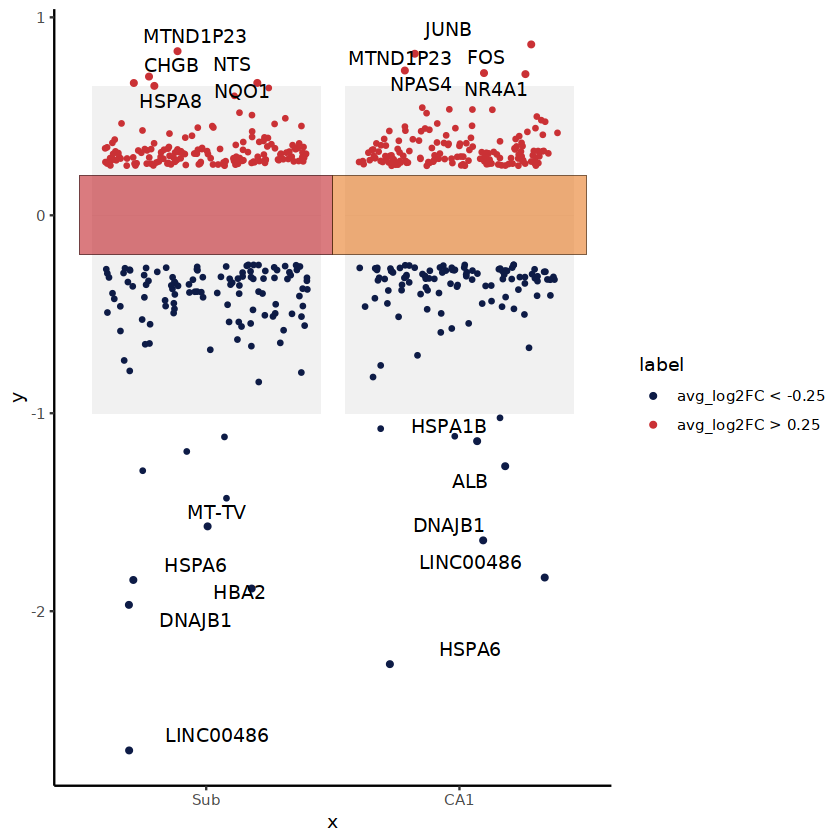

In [5]:

# 读取数据
setwd("/data/users/liuyuyang/online/08.脑区划分/02.result/01.bin100/05.AD/03.AD_vs_Con")
de = readRDS('01.bin.del_noSub.AD-vs-Con.allgenes.250224.rds')
logFCfilter = 0.25
adjPvalFilter = 0.05
pct.filter = 0.1
sig.markers = de[which(de$max.pct> pct.filter & de$p_val_adj<adjPvalFilter & abs(de$avg_log2FC)>logFCfilter),]
sig.markers$up.down = 'up'
sig.markers$up.down[which(sig.markers$avg_log2FC<0)] = 'down'
df = sig.markers#[which(sig.markers$up.down =='up'),]

df$cluster <- factor(df$cluster, levels = c("Sub", "CA1"))
df = df[order(df$cluster),]

# 添加显著性标签
df$label <- ifelse(df$avg_log2FC > 0.25, "avg_log2FC > 0.25", "avg_log2FC < -0.25")

# 获取每个cluster中表达差异最显著的10个基因（前5个最高和后5个最低）
top10.list <- list()
top10sig <- data.frame()
for (i in unique(df$cluster)) {
  top_pos <- filter(df, cluster == i) %>% distinct(gene, .keep_all = T) %>% top_n(5, avg_log2FC)
  top_neg <- filter(df, cluster == i) %>% distinct(gene, .keep_all = T) %>% top_n(5, -avg_log2FC)
  top10.list[[i]] <- rbind(top_pos, top_neg)
  top10sig <- rbind(top10sig, top10.list[[i]])
}

# 标记Top10的差异基因
df$size <- 1
df$size[which(paste0(df$cluster, "-", df$gene) %in% paste0(top10sig$cluster, "-", top10sig$gene))] <- 2

# 提取非Top10的基因表格
dt <- filter(df, size == 1)

# 绘制每个Cluster Top10以外基因的散点火山图
p <- ggplot(dt, aes(x = cluster, y = avg_log2FC, color = label)) +
  geom_jitter(size = 0.85, width = 0.4) +
  scale_color_manual(values = c("#0d1b46", "#ca3135")) +
  theme(axis.text = element_text(size = 15)) +
  scale_x_discrete(limits = c("Sub", "CA1"))  # 设置x轴顺序

# 叠加每个Cluster Top10基因散点
p <- p + geom_jitter(data = top10sig, aes(x = cluster, y = avg_log2FC, color = label), size = 1.2, width = 0.4)

# 绘制背景柱
dfbar <- data.frame(x = c("Sub", "CA1"), y = c(0.65, 0.65))
dfbar1 <- data.frame(x = c("Sub", "CA1"), y = c(-1, -1))
p1 <- ggplot() +
  geom_col(data = dfbar, aes(x = x, y = y), fill = "#dcdcdc", alpha = 0.4) +
  geom_col(data = dfbar1, aes(x = x, y = y), fill = "#dcdcdc", alpha = 0.4) +
  scale_x_discrete(limits = c("Sub", "CA1"))  # 设置x轴顺序

# 叠加散点图和背景柱
p2 <- p1 +
  geom_jitter(data = dt, aes(x = cluster, y = avg_log2FC, color = label), size = 0.85, width = 0.4) +
  geom_jitter(data = top10sig, aes(x = cluster, y = avg_log2FC, color = label), size = 1.2, width = 0.4) +
  scale_color_manual(values = c("#0d1b46", "#ca3135")) +
  theme(axis.text = element_text(size = 15))

# 添加cluster色块标签
dfcol <- data.frame(x = c("Sub", "CA1"), y = 0, label = c("Sub", "CA1"))
mycol <- cols[c("Sub","CA1")]  # 替换为您选择的颜色
p3 <- p2 + geom_tile(data = dfcol, aes(x = x, y = y), height = 0.4, color = "black", fill = mycol, alpha = 0.6, show.legend = F)

# 添加geneID标签
p4 <- p3 + geom_text_repel(data = top10sig, aes(x = cluster, y = avg_log2FC, label = gene), force = 1.2, arrow = arrow(length = unit(0.008, "npc"), type = "open", ends = "last"))

# 美化主题
p5 <- p4 + theme(axis.title.x = element_text(size = 25))+theme_classic()

# 显示图表
print(p5)

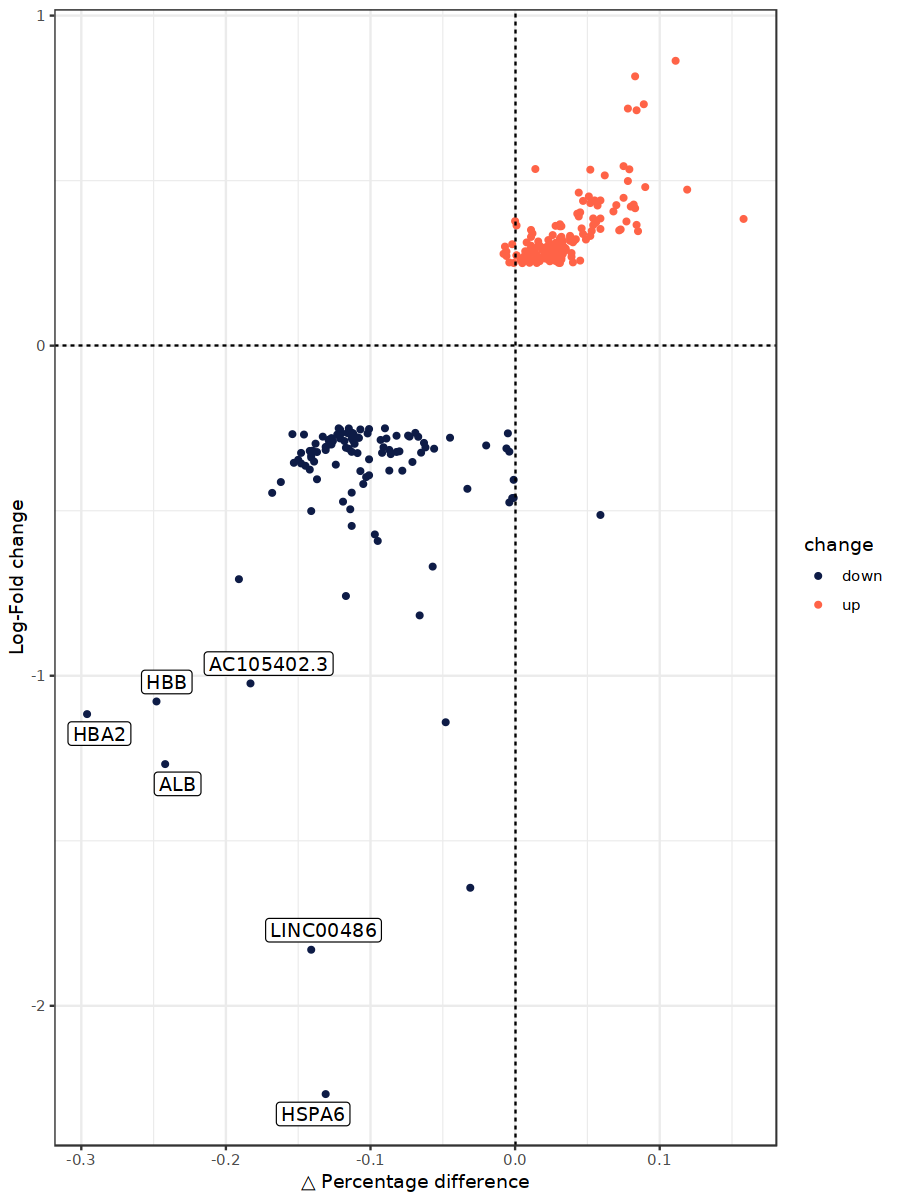

In [42]:
# 加载必要的库
library(dplyr)
library(tibble)
library(ggrepel)
setwd("/data/users/liuyuyang/online/08.脑区划分/02.result/01.bin100/05.AD/03.AD_vs_Con")

# 假设 markers 是一个数据框，您需要根据实际情况定义它
# markers <- data.frame(...)  # 在这里定义您的 markers 数据框
df = sig.markers[sig.markers$cluster=='CA1',]
# 计算差异并添加基因名列
markers <- df %>%
  mutate(Difference = pct.1 - pct.2) 
markers$change = markers$up.down

# 假设 markers 数据框已经定义并包含必要的列

# 绘制火山图
ggplot(markers, aes(x = Difference, y = avg_log2FC, color = change)) +
  geom_point(size = 1.2) +
  scale_color_manual('change', 
                     # labels = c(paste0("down(", table(markers$change)[[1]], ')'),
                     #             'ns',
                     #             paste0("up(", table(markers$change)[[3]], ')')),
                     values = c("#0d1b46", "tomato")) +# "grey",
  geom_label_repel(data = subset(markers, 
                                 avg_log2FC >= 1 & Difference >= 0.1 & p_val_adj <= 0.05), 
                   aes(label = gene),  # 添加label
                   color = "black",    # 设置label中标签的颜色
                   segment.colour = "black",  # 设置label框的颜色
                   label.padding = 0.2, 
                   segment.size = 0.3,  # 框的大小
                   size = 4,
                   max.overlaps = 20) +  # 增加 max.overlaps 参数
  geom_label_repel(data = subset(markers, 
                                 avg_log2FC <= -1 & Difference <= -0.1 & p_val_adj <= 0.05), 
                   aes(label = gene), 
                   label.padding = 0.2, 
                   color = "black",
                   segment.colour = "black",
                   segment.size = 0.3, size = 4,
                   max.overlaps = 20) +
  geom_vline(xintercept = 0, linetype = 2) +
  geom_hline(yintercept = 0, linetype = 2) +
  labs(x = "△ Percentage difference", y = "Log-Fold change") +
  theme_bw()


png 
  2

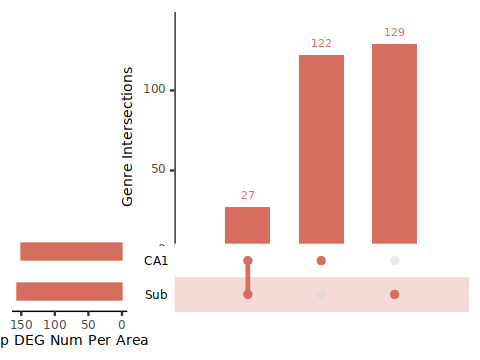

In [6]:
de = readRDS('01.bin.del_noSub.AD-vs-Con.allgenes.250224.rds')
logFCfilter = 0.25
adjPvalFilter = 0.05
pct.filter = 0.1
sig.markers = de[which(de$max.pct> pct.filter & de$p_val_adj<adjPvalFilter & abs(de$avg_log2FC)>logFCfilter),]
sig.markers$up.down = 'up'
sig.markers$up.down[which(sig.markers$avg_log2FC<0)] = 'down'

de.up = sig.markers[which(sig.markers$up.down =='up'),]
de.up$value = 1

de.up = de.up[,c('gene','cluster','value')]
data_wide <- de.up %>%  pivot_wider(names_from = cluster ,values_from = value)
data_wide[is.na(data_wide)]=0

upset_dat = data.frame(data_wide,check.names=F)
row.gene = upset_dat$gene

upset_dat = upset_dat[,2:3]
upset_dat = upset_dat %>% data.frame() %>% mutate(across(where(is.character), as.numeric))

# upset_dat[1:3,]
upset_dat$gene = row.gene

# upset_list <- list(upset_dat[,1],upset_dat[,2], upset_dat[,3], upset_dat[,4], upset_dat[,5], upset_dat[,6], upset_dat[,7])   # 制作Upset图搜所需要的列表文件

# ###列名
# names(upset_list) <- colnames(upset_dat)[1:7]  # 把列名赋值给列表的key值


# names(upset_list)
# names(upset_list) = gsub("CA1.3","CA1-3",names(upset_list))

# upset_dat = data.frame(data_wide,check.names=F)
# upset_dat[1:3,]

library(UpSetR) # 加载R包

colo = '#d56e5e'

options(repr.plot.width = 4,repr.plot.height = 3)
pdf('/data/work/脑区划分/01_result/03.up_upset.pdf',width = 4,height = 4.5)
p = upset(data = upset_dat,
      sets = c("Sub","CA1") , # 指定集合
      keep.order = T,
      main.bar.color = colo ,matrix.color= colo ,sets.bar.color= colo ,att.color= colo ,shade.color= colo,
      number.angles = 0, # 设置交互集合柱状图上方数字的角度
      point.size = 2, # 设置矩阵中圆圈的大小
      line.size = 1, # 设置矩阵中连接圆圈的线的大小
      mainbar.y.label = "Genre Intersections", # 设置y轴标签
      sets.x.label = "Up DEG Num Per Area", # 设置x轴标签
      mb.ratio = c(0.65, 0.3), # 设置bar plot和matrix plot图形高度的占比
      order.by = "degree",  # 设置矩阵中的交点应该如何排列  #freq代表频率，degree代表点连接的数量
      nintersects = 100) #集合数量
p
dev.off()
p

In [9]:
upset_dat[upset_dat$gene%in%c('JUNB','PLK2','NDUFA4','CLAM2'),]

,Sub,CA1,gene
,<dbl>,<dbl>,<chr>
6,1,0,NDUFA4
64,1,1,JUNB
138,1,0,PLK2


In [56]:
de = readRDS('01.bin.del_noSub.AD-vs-Con.allgenes.250224.rds')
logFCfilter = 0.25
adjPvalFilter = 0.05
pct.filter = 0.1
sig.markers = de[which(de$max.pct> pct.filter & de$p_val_adj<adjPvalFilter & abs(de$avg_log2FC)>logFCfilter),]
sig.markers$up.down = 'up'
sig.markers$up.down[which(sig.markers$avg_log2FC<0)] = 'down'

de.up = sig.markers[which(sig.markers$up.down =='down'),]
de.up$value = 1

de.up = de.up[,c('gene','cluster','value')]
data_wide <- de.up %>%  pivot_wider(names_from = cluster ,values_from = value)
data_wide[is.na(data_wide)]=0

upset_dat = data.frame(data_wide,check.names=F)
row.gene = upset_dat$gene

upset_dat = upset_dat[,2:3]
upset_dat = upset_dat %>% data.frame() %>% mutate(across(where(is.character), as.numeric))

# upset_dat[1:3,]
upset_dat$gene = row.gene

library(UpSetR) # 加载R包

colo = '#4276CC'

options(repr.plot.width = 4,repr.plot.height = 3)
pdf('/data/work/脑区划分/01_result/03.down_upset.pdf',width = 4,height = 4.5)
upset(data = upset_dat,
      sets = c("Sub","CA1") , # 指定集合
      keep.order = T,
      main.bar.color = colo ,matrix.color= colo ,sets.bar.color= colo ,att.color= colo ,shade.color= colo,
      number.angles = 0, # 设置交互集合柱状图上方数字的角度
      point.size = 2, # 设置矩阵中圆圈的大小
      line.size = 1, # 设置矩阵中连接圆圈的线的大小
      mainbar.y.label = "Genre Intersections", # 设置y轴标签
      sets.x.label = "Up DEG Num Per Area", # 设置x轴标签
      mb.ratio = c(0.6, 0.4), # 设置bar plot和matrix plot图形高度的占比
      order.by = "degree",  # 设置矩阵中的交点应该如何排列  #freq代表频率，degree代表点连接的数量
      nintersects = 100) #集合数量
dev.off()


png 
  2

In [4]:
suppressMessages({
library(Seurat)
library("clusterProfiler")
library("org.Hs.eg.db")
library("enrichplot")
library("ggplot2")
library(dplyr)
})

In [33]:
setwd("/data/users/liuyuyang/online/08.脑区划分/02.result/01.bin100/05.AD/03.AD_vs_Con")
de = readRDS('01.bin.del_noSub.AD-vs-Con.allgenes.250224.rds')
logFCfilter = 0.25
adjPvalFilter = 0.05
pct.filter = 0.1
sig.markers = de[which(de$max.pct> pct.filter & de$p_val_adj<adjPvalFilter & abs(de$avg_log2FC)>logFCfilter),]
sig.markers$up.down = 'up'
sig.markers$up.down[which(sig.markers$avg_log2FC<0)] = 'down'
de.up = sig.markers[which(sig.markers$up.down =='up'),]

GO.combined = c()
for(i in unique(de.up$cluster)){
  temp = de.up[which(de.up$cluster %in% i),]
  #temp = DE.combine[which(paste0(DE.combine$class,"_",DE.combine$up.down) %in% i),]
  
  #mygene <- AnnotationDbi::select(org.Hs.eg.db,columns=c("SYMBOL","ENTREZID"),keytype="SYMBOL",keystype="SYMBOL",keys=temp$gene)
  mygene <- tryCatch(
    { AnnotationDbi::select(org.Hs.eg.db,columns=c("SYMBOL","ENTREZID"),keys=temp$gene,keytype="SYMBOL") },
    warning = function(w) { message('Waring @ ',temp$gene) ; return(NA) },
    error = function(e) { message('Error @ ',temp$gene) ; return(NA) },
    finally = { message('next...') }
  )
  
   if (is.na(data.frame(mygene)[1,1])=="FALSE"){
      mygene<-mygene$ENTREZID
      ego <- enrichGO(gene = mygene,OrgDb = org.Hs.eg.db,ont = "ALL",pAdjustMethod = "BH",pvalueCutoff = 1,qvalueCutoff = 1,readable = TRUE) 
      
      # GO.list = ego@result
      GO.list <- tryCatch(
          { ego@result },
          warning = function(w) { message('Waring @ ',mygene) ; return(NA) },
          error = function(e) { message('Error @ ',mygene) ; return(NA) },
          finally = { message('next...') }
      )
      if (is.na(data.frame(GO.list)[1,1])==FALSE){
          GO.list$cluster = i
          GO.combined = rbind(GO.combined,GO.list)
      }else{print('GO_list is NA')}
      
  }else{print("None of the keys entered are valid keys for 'SYMBOL:")}
  print(i)
    mygene = c()
    GO.list = c()
}

GO.combined.filter = GO.combined[GO.combined$p.adjust < 0.05,]
write.csv(GO.combined.filter,"/data/work/脑区划分/01_result/02.bin.del_noSub.AD_vs_Con.up.GO.filter.250225.csv")

'select()' returned 1:1 mapping between keys and columns

next...

next...



[1] "Sub"


'select()' returned 1:1 mapping between keys and columns

next...

next...



[1] "CA1"


In [34]:
GO.combined = c()
de.down = sig.markers[which(sig.markers$up.down =='down'),]
for(i in unique(de.down$cluster)){
  temp = de.down[which(de.down$cluster %in% i),]
  #temp = DE.combine[which(paste0(DE.combine$class,"_",DE.combine$up.down) %in% i),]
  
  #mygene <- AnnotationDbi::select(org.Hs.eg.db,columns=c("SYMBOL","ENTREZID"),keytype="SYMBOL",keystype="SYMBOL",keys=temp$gene)
  mygene <- tryCatch(
    { AnnotationDbi::select(org.Hs.eg.db,columns=c("SYMBOL","ENTREZID"),keys=temp$gene,keytype="SYMBOL") },
    warning = function(w) { message('Waring @ ',temp$gene) ; return(NA) },
    error = function(e) { message('Error @ ',temp$gene) ; return(NA) },
    finally = { message('next...') }
  )
  
   if (is.na(data.frame(mygene)[1,1])=="FALSE"){
      mygene<-mygene$ENTREZID
      ego <- enrichGO(gene = mygene,OrgDb = org.Hs.eg.db,ont = "ALL",pAdjustMethod = "BH",pvalueCutoff = 1,qvalueCutoff = 1,readable = TRUE) 
      
      # GO.list = ego@result
      GO.list <- tryCatch(
          { ego@result },
          warning = function(w) { message('Waring @ ',mygene) ; return(NA) },
          error = function(e) { message('Error @ ',mygene) ; return(NA) },
          finally = { message('next...') }
      )
      if (is.na(data.frame(GO.list)[1,1])==FALSE){
          GO.list$cluster = i
          GO.combined = rbind(GO.combined,GO.list)
      }else{print('GO_list is NA')}
      
  }else{print("None of the keys entered are valid keys for 'SYMBOL:")}
  print(i)
    mygene = c()
    GO.list = c()
}

GO.combined.filter = GO.combined[GO.combined$p.adjust < 0.05,]
write.csv(GO.combined.filter,"/data/work/脑区划分/01_result/02.bin.del_noSub.AD_vs_Con.down.GO.filter.250225.csv")

'select()' returned 1:1 mapping between keys and columns

next...

next...



[1] "Sub"


'select()' returned 1:1 mapping between keys and columns

next...

next...



[1] "CA1"


In [67]:
library(dplyr)
library(stringdist)

# 创建一个函数来检查相似性
is_similar <- function(desc1, desc2, threshold = 0.1) {
  return(stringdist::stringdist(desc1, desc2) < threshold)
}

# 去除相似项的逻辑
GO.combined.top.BP <- GO.combined.top.BP %>%
  group_by(cluster) %>%
  filter(!duplicated(Description) & !sapply(Description, function(x) any(sapply(Description, function(y) is_similar(x, y)))))  %>%
  ungroup()
GO.combined.top.BP

ERROR: Error in library(stringdist): there is no package called ‘stringdist’


png 
  2

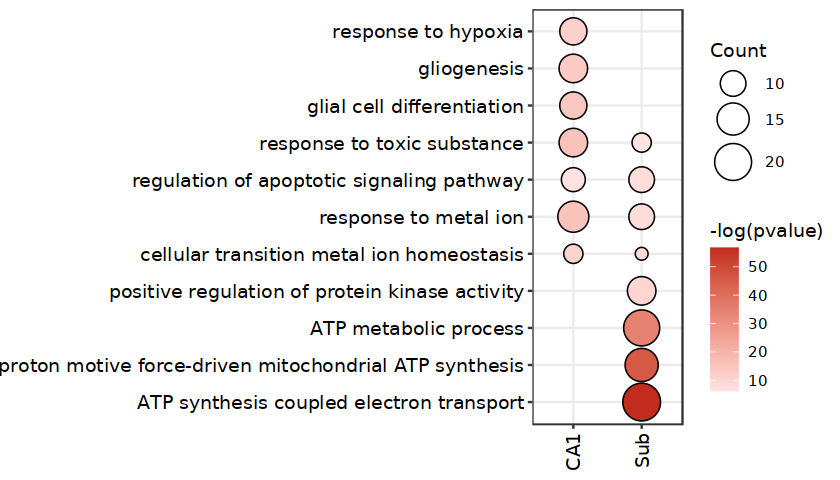

In [91]:
GO.combined.top.BP = read.csv("/data/work/脑区划分/01_result/02.bin.del_noSub.AD_vs_Con.up.GO.filter.250225.csv")
terms <-unique( c(
  "ATP synthesis coupled electron transport",
  "ATP metabolic process",
  "proton motive force-driven mitochondrial ATP synthesis",
  "response to metal ion",
  "positive regulation of protein kinase activity",
  "response to toxic substance",
  "gliogenesis",
  "glial cell differentiation",
  "response to hypoxia",
  "response to metal ion",
  "regulation of apoptotic signaling pathway",
  "regulation of apoptotic signaling pathway",
  "cellular transition metal ion homeostasis",
  "cellular transition metal ion homeostasis"
))

GO.combined.top.BP = GO.combined.top.BP[GO.combined.top.BP$Description%in%c(terms),]
GO.combined.top.BP = GO.combined.top.BP[GO.combined.top.BP$ONTOLOGY=="BP",]
# GO.combined.top.BP = GO.combined.top.BP %>% group_by(cluster) %>% top_n(20,Count)
# #GO.combined.top.BP$cluster = factor(GO.combined.top.BP$cluster,levels = unique(GO.combined.top.BP$cluster))
# GO.combined.top.BP = GO.combined.top.BP[order(GO.combined.top.BP$cluster,-GO.combined.top.BP$Count),]
GO.combined.top.BP$Description = factor(GO.combined.top.BP$Description,levels = unique(GO.combined.top.BP$Description))
library(viridis)
options(repr.plot.width = 7,repr.plot.height = 4)

p1 = ggplot(GO.combined.top.BP, aes(cluster, Description)) +
  geom_point(aes(fill = -log(pvalue), size = Count), shape = 21) +
  theme_bw() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5),
        axis.text = element_text(color = 'black', size = 11)) +
  scale_fill_gradient(low = "#ffe3e3", high = "#c12c1f") + # 红色渐变
  labs(x = NULL, y = NULL) +
  scale_size_continuous(range = c(3, 10)) # 调整圆圈大小范围

p1


pdf("/data/work/脑区划分/01_result/02.AD_up.GO_BP_term.top10.bubble.pdf",width = 7,height = 5)#width = length(unique(combined.top$Description)),height = length(unique(combined.top$cluster)))
print(p1)
dev.off()

png 
  2

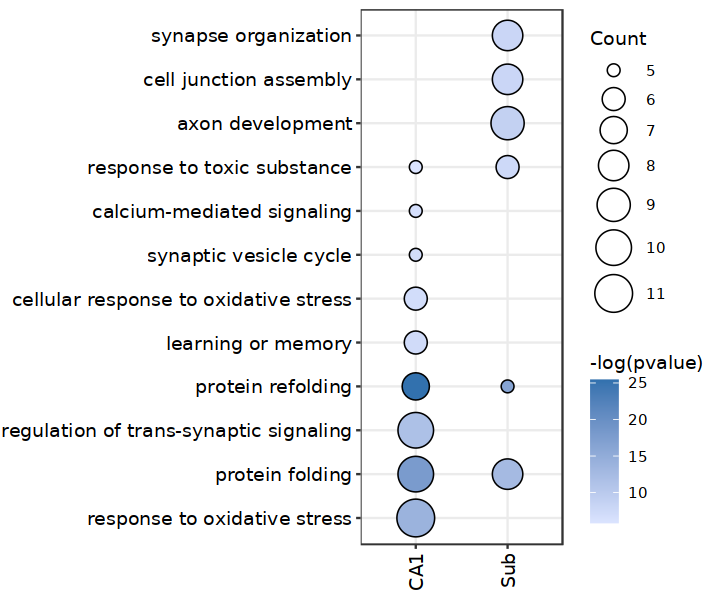

In [94]:
GO.combined.top.BP = read.csv("/data/work/脑区划分/01_result/02.bin.del_noSub.AD_vs_Con.down.GO.filter.250225.csv")
terms <- unique( c(
  "response to oxidative stress",
  "protein folding",
  "regulation of trans-synaptic signaling",
  "axon development",
  "protein folding",
  "cell junction assembly",
  "synapse organization",
  "protein refolding",
  "response to toxic substance",
  "learning or memory",
  "cellular response to oxidative stress",
  "protein refolding",
  "synaptic vesicle cycle",
  "calcium-mediated signaling",
  "response to toxic substance"
))
GO.combined.top.BP = GO.combined.top.BP[GO.combined.top.BP$Description%in%c(terms),]

GO.combined.top.BP = GO.combined.top.BP[GO.combined.top.BP$ONTOLOGY=="BP",]
GO.combined.top.BP = GO.combined.top.BP %>% group_by(cluster) %>% top_n(20,Count)
#GO.combined.top.BP$cluster = factor(GO.combined.top.BP$cluster,levels = unique(GO.combined.top.BP$cluster))
GO.combined.top.BP = GO.combined.top.BP[order(GO.combined.top.BP$cluster,-GO.combined.top.BP$Count),]
GO.combined.top.BP$Description = factor(GO.combined.top.BP$Description,levels = unique(GO.combined.top.BP$Description))
library(viridis)
options(repr.plot.width = 6,repr.plot.height = 5)

p1 = ggplot(GO.combined.top.BP, aes(cluster, Description )) +
          geom_point(aes(fill=-log(pvalue), size=Count), shape=21)+
          theme_bw()+
          theme(axis.text.x=element_text(angle=90,hjust = 1,vjust=0.5),
          axis.text = element_text(color = 'black', size = 11))+
          scale_fill_gradient(low="#dbe4ff",high="#3271ae")+ 

          labs(x=NULL,y=NULL) +
  scale_size_continuous(range = c(3, 10)) # 调整圆圈大小范围
p1

pdf("/data/work/脑区划分/01_result/02.AD_down.GO_BP_term.top10.bubble.pdf",width = 6,height = 5)#width = length(unique(combined.top$Description)),height = length(unique(combined.top$cluster)))
print(p1)
dev.off()

In [3]:
######WGCNA

suppressMessages({
library(hdWGCNA)
library(WGCNA)

library(Seurat)
library(clustree)
library(dplyr)
library(patchwork)
library(RColorBrewer)

})

cols = c(brewer.pal(9, "Set1"),brewer.pal(8,"Set2")[1:8],brewer.pal(12,"Paired")[1:12],brewer.pal(8,"Dark2")[1:8],brewer.pal(8,"Accent"),brewer.pal(12, "Set3"),brewer.pal(9,"Pastel1"),brewer.pal(8,"Pastel2"))
cols = c(cols,cols)


In [ ]:
seurat_obj = readRDS('/data/users/liuyuyang/online/08.脑区划分/02.result/01.bin100/05.AD/04.wgcna/pca.bin_Sub_CA1.hdWGCNA_object_total.rds')

pickSoftThreshold: will use block size 1416.
 pickSoftThreshold: calculating connectivity for given powers...
   ..working on genes 1 through 1416 of 1416


Warning message:
“executing %dopar% sequentially: no parallel backend registered”
Warning message in (function (x, y = NULL, robustX = TRUE, robustY = TRUE, use = "all.obs", :
“bicor: zero MAD in variable 'x'. Pearson correlation was used for individual columns with zero (or missing) MAD.”
Warning message in (function (x, y = NULL, robustX = TRUE, robustY = TRUE, use = "all.obs", :
“bicor: zero MAD in variable 'y'. Pearson correlation was used for individual columns with zero (or missing) MAD.”


   Power SFT.R.sq slope truncated.R.sq  mean.k. median.k. max.k.
1      1   0.4900 32.30          0.809 715.0000  7.17e+02 747.00
2      2   0.0879  5.01          0.934 380.0000  3.79e+02 438.00
3      3   0.0738 -2.25          0.796 212.0000  2.09e+02 285.00
4      4   0.6560 -4.12          0.942 123.0000  1.19e+02 197.00
5      5   0.7380 -3.34          0.962  73.5000  6.98e+01 142.00
6      6   0.7950 -2.91          0.970  45.5000  4.23e+01 105.00
7      7   0.8140 -2.59          0.965  29.0000  2.59e+01  80.10
8      8   0.8510 -2.33          0.982  18.9000  1.63e+01  62.00
9      9   0.8680 -2.21          0.976  12.7000  1.04e+01  48.70
10    10   0.8780 -2.12          0.957   8.6500  6.73e+00  38.70
11    12   0.8710 -2.03          0.930   4.2700  2.93e+00  25.30
12    14   0.9160 -1.92          0.981   2.2600  1.31e+00  17.30
13    16   0.9000 -1.87          0.944   1.2700  6.06e-01  12.20
14    18   0.8730 -1.85          0.923   0.7540  2.90e-01   8.73
15    20   0.3130 -2.80  

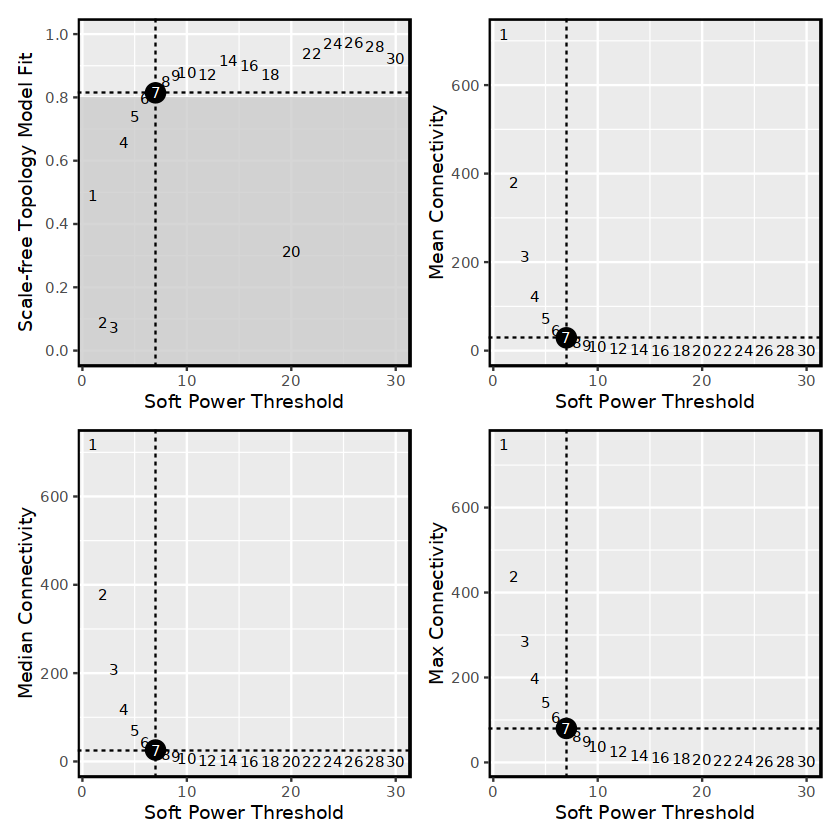

In [4]:
# Test different soft powers:
seurat_obj <- TestSoftPowers(
  seurat_obj,
  networkType = 'signed' # you can also use "unsigned" or "signed hybrid"
)

# seurat_obj <- TestSoftPowers(
#   seurat_obj,
#   networkType = 'signed hybrid', 
#   setDatExpr = FALSE
# )  


# plot the results:
plot_list <- PlotSoftPowers(seurat_obj) #阈值

# assemble with patchwork
wrap_plots(plot_list, ncol=2)

In [5]:
setwd('/data/work/脑区划分/01_result')
library(future)
options(future.globals.maxSize = 200 * 1000 *1024^2 )
# plan()
plan("multisession", workers = 16)
# plan()


Warning message in getCGroups2CpuMax():
“[INTERNAL]: Will ignore the cgroups CPU quota, because it is out of range [1,40]: 64”


In [6]:
seurat_obj <- ConstructNetwork(
  seurat_obj, soft_power=7, #软阈值的选择
  setDatExpr=FALSE,
 #tom_name = "new_TOM_name",
  #tom_name = class, # name of the topoligical overlap matrix written to disk
  corType = "pearson", #计算相关性的方法；可选pearson(默认)，bicor。后者更能考虑离群点的影响。
  networkType = "signed", #计算邻接矩阵时，是否考虑正负相关性；"unsigned","signed", "signed hybrid"
  TOMType = "signed 2", #计算TOM矩阵时，是否考虑正负相关性,选择"none", "unsigned", "signed", "signed Nowick", "unsigned 2", "signed 2" and "signed Nowick 2"
  detectCutHeight = 1,#detectCutHeight参数是用于确定模块数量的高度阈值。降低该参数的值可以使更多的模块被检测出来
  minModuleSize = 20, #模块的最少基因数
  # mergeCutHeight = 0.2, #合并模块的阈值,两个模块的相似性得分高于0.2时将它们合并成一个模块。
  overwrite_tom = TRUE # 将overwrite_tom参数设置为TRUE
)

Warning message in ConstructNetwork(seurat_obj, soft_power = 7, setDatExpr = FALSE, :
“Overwriting TOM TOM/CA1_Sub_TOM.rda”


 Calculating consensus modules and module eigengenes block-wise from all genes
 Calculating topological overlaps block-wise from all genes
   Flagging genes and samples with too many missing values...
    ..step 1
    TOM calculation: adjacency..
    ..will not use multithreading.
     Fraction of slow calculations: 0.000000
    ..connectivity..
    ..matrix multiplication (system BLAS)..
    ..normalization..
    ..done.
 ..Working on block 1 .
 ..Working on block 1 .
 ..merging consensus modules that are too close..


In [8]:
modules = seurat_obj@misc$CA1_Sub$wgcna_modules
net <- GetNetworkData(seurat_obj)
# modules[modules$module=='black',]$module = 'orange'
modules$module <- factor(modules$module)
modules[modules$color=='grey',]$color = '#eaebea'
modules[modules$color=='blue',]$color = '#6e9bc5'
modules[modules$color=='red',]$color = '#e94829'
modules[modules$color=='yellow',]$color = '#ffee6f'
modules[modules$color=='green',]$color = '#199a73'
modules[modules$color=='magenta',]$color = '#984EA3'
modules[modules$color=='pink',]$color = '#e15987'
modules[modules$color=='black',]$color = '#fd7c01'

In [32]:
options(repr.plot.width=12, repr.plot.height=4)   ##图像界面宽度显示设置
 pdf('/data/work/脑区划分/01_result/CA1_Sub_Dendrogram_allgene.pdf',width = 12,height = 2)

WGCNA::plotDendroAndColors(
    net$dendrograms[[1]],
    as.character(modules$color),
    groupLabels='Module colors',
    dendroLabels = FALSE,
    hang = 0.03,
    addGuide = TRUE,
    guideHang = 0.05,
    # main = main,

  )
dev.off()


png 
  2

In [31]:
table(seurat_obj@misc$CA1_Sub$wgcna_modules$module) 
Gene2Module = seurat_obj@misc$CA1_Sub$wgcna_modules
write.csv(Gene2Module,"Sub_CA1.Module.csv")


     blue      pink      grey     brown    yellow     black     green turquoise 
      141        41       611       137        98        48        71       143 
      red    purple   magenta 
       66        25        35 

In [33]:
#可以使用模块特征值（Module eigengene ME）开展模块与模块的相关性分析，或者与性状的相关性分析，得出与感兴趣的性状最相关的模块出来
#ME是将模块内的基因进行PCA分析，得到PC1值。PC1值可整体描述模块中基因的变化模式
# need to run ScaleData first or else harmony throws an error:
seurat_obj <- ScaleData(seurat_obj)
# compute all MEs in the full single-cell dataset
seurat_obj <- ModuleEigengenes(
  seurat_obj,scale.model.use = "linear"           ## group.by.vars="Sample"ww
)

# module eigengenes:
MEs <- GetMEs(seurat_obj, harmonized=FALSE)
hMEs <- GetMEs(seurat_obj)    ##默认用harmony后的
head(hMEs)   ##得到模块与细胞的相关性
# write.table(MEs,paste0(output,"/MEs.csv"),row.names = FALSE,sep = ",",quote = FALSE)
# saveRDS(seurat_obj, "bin_Sub_CA1.hdWGCNA_object_total.rds")


Centering and scaling data matrix



[1] "blue"


Centering and scaling data matrix

Warning message:
“Keys should be one or more alphanumeric characters followed by an underscore, setting key from pcablue to pcablue_”
Warning message:
“All keys should be one or more alphanumeric characters followed by an underscore '_', setting key to pcablue_”
pcablue_ 1 
Positive:  IFI44L, RPP38, HBB, TFE3, IFIT2, TUBB, TUT4, RSAD2, KCNK12, ADAM15 
	   ZNF451, PAK5, MBD3, AC005833.1, MX1, DPYSL5, ABL1, DDX21, ASAP1, R3HDM1 
	   PVT1, CLK1, UIMC1, ISG15, TRAF3, SGCZ, PFKL, PDPR, NPAS1, AL137782.1 
Negative:  HSPA6, LINC00486, DNAJB1, HELLPAR, HSPA1B, LINC02087, HSPB1, AL592295.3, AC103843.1, AC020656.1 
	   AL358075.2, AC098829.1, MATN1, HMOX1, AC051619.4, NPTX2, EFCAB8, BAG3, HSPH1, DNAJA4 
	   FARP2, RRAD, SERPINH1, AL158850.1, AC009163.4, CCDC62, TSACC, UBC, HSPD1, RN7SL832P 
pcablue_ 2 
Positive:  IFIT3, ISG15, SERPINB9, HBA2, OTULINL, HBA1, MX1, AL158850.1, IFI44L, LUCAT1 
	   RN7SL832P, RSAD2, PIGN, IFIT2, FBXL18, TSACC, HBB, AC103843.1, AC008

[1] "pink"


Centering and scaling data matrix

Warning message in irlba(A = t(x = object), nv = npcs, ...):
“You're computing too large a percentage of total singular values, use a standard svd instead.”
Warning message in irlba(A = t(x = object), nv = npcs, ...):
“did not converge--results might be invalid!; try increasing work or maxit”
Warning message:
“Keys should be one or more alphanumeric characters followed by an underscore, setting key from pcapink to pcapink_”
Warning message:
“All keys should be one or more alphanumeric characters followed by an underscore '_', setting key to pcapink_”
Warning message:
“Requested number is larger than the number of available items (41). Setting to 41.”
Warning message:
“Requested number is larger than the number of available items (41). Setting to 41.”
Warning message:
“Requested number is larger than the number of available items (41). Setting to 41.”
Warning message:
“Requested number is larger than the number of available items (41). Setting to 41.”


...

[1] "purple"


Centering and scaling data matrix

Warning message in irlba(A = t(x = object), nv = npcs, ...):
“You're computing too large a percentage of total singular values, use a standard svd instead.”
Warning message in irlba(A = t(x = object), nv = npcs, ...):
“did not converge--results might be invalid!; try increasing work or maxit”
Warning message:
“Keys should be one or more alphanumeric characters followed by an underscore, setting key from pcapurple to pcapurple_”
Warning message:
“All keys should be one or more alphanumeric characters followed by an underscore '_', setting key to pcapurple_”
Warning message:
“Requested number is larger than the number of available items (25). Setting to 25.”
Warning message:
“Requested number is larger than the number of available items (25). Setting to 25.”
Warning message:
“Requested number is larger than the number of available items (25). Setting to 25.”
Warning message:
“Requested number is larger than the number of available items (25). Setting to

[1] "magenta"


Centering and scaling data matrix

Warning message in irlba(A = t(x = object), nv = npcs, ...):
“You're computing too large a percentage of total singular values, use a standard svd instead.”
Warning message in irlba(A = t(x = object), nv = npcs, ...):
“did not converge--results might be invalid!; try increasing work or maxit”
Warning message:
“Keys should be one or more alphanumeric characters followed by an underscore, setting key from pcamagenta to pcamagenta_”
Warning message:
“All keys should be one or more alphanumeric characters followed by an underscore '_', setting key to pcamagenta_”
Warning message:
“Requested number is larger than the number of available items (35). Setting to 35.”
Warning message:
“Requested number is larger than the number of available items (35). Setting to 35.”
Warning message:
“Requested number is larger than the number of available items (35). Setting to 35.”
Warning message:
“Requested number is larger than the number of available items (35). Setting

,pink,magenta,blue,green,turquoise,brown,red,grey,black,yellow,purple
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Con1.1_Con1.1_BIN100_491,7.189371,-2.0331316,-2.076534,-0.1840878,-5.087938,1.189920,-4.294168,-5.472593,-0.03610681,1.138405,-2.128400
Con1.1_Con1.1_BIN100_518,5.574206,-1.8735437,-2.375030,4.0960051,-5.899729,9.133843,2.860611,-1.594082,3.12105759,9.702152,-2.350228
Con1.1_Con1.1_BIN100_520,6.046917,-2.2741828,-3.221623,2.3854525,-4.928208,8.619397,3.234015,-1.251735,3.65500781,8.673211,-2.349047
Con1.1_Con1.1_BIN100_522,5.391937,-2.1581786,-4.048259,-0.4358764,-6.688277,3.033761,-4.124518,-5.831644,-1.80146577,3.236294,-2.647185
Con1.1_Con1.1_BIN100_530,6.976320,-2.4476129,-2.493613,-0.1874024,-6.385298,1.678175,-3.825034,-9.320066,-2.99441806,2.713698,-1.044792
Con1.1_Con1.1_BIN100_535,6.007360,-0.4107065,-3.180119,1.0812960,-5.994435,2.212154,-2.493276,-5.383271,-0.86707054,5.683221,-1.907384


In [34]:
seurat_obj$group_area = paste0(seurat_obj$group,'_',seurat_obj$area)
seurat_obj@meta.data[1:2,]
##Calculate the correlation between traits and samples
DMEs_all <- FindAllDMEs(
  seurat_obj,
  group.by = 'group_area'
)


,orig.ident,nCount_RNA,nFeature_RNA,chip,nFeature_Spatial,nCount_Spatial,rx,ry,rx.m,ry.m,⋯,coor_y,coor_x,row,col,cell,label,group,person,metacell_grouping,group_area
,<chr>,<dbl>,<int>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
Con1.1_Con1.1_BIN100_491,Con1.1,3422,951,Con1.1,951,3422,0,0,0,477,⋯,477,0,NA,NA,NA,Con1.1_NA_NA,Con,Con1,Sub#Con,Con_Sub
Con1.1_Con1.1_BIN100_518,Con1.1,2166,865,Con1.1,865,2166,0,0,0,450,⋯,450,0,NA,NA,NA,Con1.1_NA_NA,Con,Con1,Sub#Con,Con_Sub


[1] "Con_Sub"
[1] "Con_CA1"
[1] "AD_CA1"
[1] "AD_Sub"


In [12]:
# get the modules table:
modules <- GetModules(seurat_obj)
mods <- levels(modules$module); mods <- mods[mods != 'grey']

In [36]:
library(tidyr)
plot_df = DMEs_all
plot_df1 = plot_df
plot_df1$group_module = row.names(plot_df1)

logfc_df = plot_df1[,c('avg_log2FC','group','module')]
pvalue_df = plot_df1[,c('p_val_adj','group','module')]

#logfc_df
logfc_wide<-tidyr::spread(logfc_df,group,avg_log2FC) #year为需要分解的变量，gdp为分解后的列的取值
row.names(logfc_wide) = logfc_wide$module
logfc_wide = logfc_wide[,-1]
logfc_wide = data.frame(t(logfc_wide),check.names=F)
# logfc_wide[1:2,]

#pvalue_df
pvalue_wide<-tidyr::spread(pvalue_df,group,p_val_adj) #year为需要分解的变量，gdp为分解后的列的取值
row.names(pvalue_wide) = pvalue_wide$module
pvalue_wide = pvalue_wide[,-1]
pvalue_wide = data.frame(t(pvalue_wide),check.names=F)

### 统一两个df横纵坐标
logfc_wide = logfc_wide[rev(c('Con_CA1','Con_Sub','AD_CA1','AD_Sub')),]

pvalue_wide = pvalue_wide[,colnames(logfc_wide) ]
pvalue_wide = pvalue_wide[row.names(logfc_wide), ]

#判断显著性
pmat = pvalue_wide## 先复制一个表格


if(!is.null(pmat) ){
    ssmt <- pmat < 0.001
    pmat[ssmt] <- '***'
    smt <- pmat < 0.01 & pmat >= 0.001
    pmat[smt] <- '**'
    tmat <- pmat < 0.05 & pmat >= 0.01
    pmat[tmat] <- '*'
    pmat[!ssmt & !smt & !tmat]<- ''
}else{
    pmat <- F
}

pmat = as.matrix(pmat)
# pmat

library(ComplexHeatmap)
col_fun = circlize::colorRamp2(c(-6, 0,2),  c("#588dd5", "#fbfbfb", "#f5994e") ) #c("#3C5088","white","#A6443D"))
p = Heatmap(logfc_wide ,cluster_rows = F,cluster_columns = F,#row_split = row.type,#column_order = order(colnames(mat_scaled)),
          # left_annotation = left_anno,
            # column_names_gp = gpar(fontsize = 14, angle = 75), # 设置列名字体大小和旋转角度
            cell_fun = function(j, i, x, y, width, height, fill) {
                # 获取pmat对应位置的星号标记
                star_symbol = pmat[i, j]
                grid.text(star_symbol, x, y, gp = gpar(fontsize = 10))
            },
            width = ncol(logfc_wide)*unit(10, "mm"), height = nrow(logfc_wide)*unit(10, "mm"),## 方块cell大小
            col = col_fun,column_names_rot = 75 )

p

pdf('02.group_area.module.cor.pdf',width = 6,height = 6)
p
dev.off()

Loading required package: grid

ComplexHeatmap version 2.14.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))


Warning message:
“The input is a data frame-like object, convert it to a matrix.”


png 
  2

In [10]:
TOM <- GetTOM(seurat_obj)

In [38]:
saveRDS(TOM,'/data/work/脑区划分/00_data/CA1_Sub_tom.rds')

In [13]:
MEs <- GetMEs(seurat_obj, harmonized=FALSE)
head(MEs)
modules <- GetModules(seurat_obj)
mods <- levels(modules$module); mods <- mods[mods != 'grey']

# add the MEs to the seurat metadata so we can plot it with Seurat functions
seurat_obj@meta.data <- cbind(seurat_obj@meta.data, MEs)

NULL

ERROR: Error in data.frame(..., check.names = FALSE): arguments imply differing number of rows: 157009, 0


In [55]:
# Create the DotPlot
Order = c('pink','green','turquoise','red','black','brown','yellow','blue','magenta')
seurat_obj$mods = factor(seurat_obj$mods,levels = Order)
p <- DotPlot(seurat_obj, features=mods, group.by = 'group_area', dot.min=0.2)

# Customize the plot
p <- p +
  scale_color_gradient2(high='#f5994e', mid='#fbfbfb', low='#588dd5') +
  xlab('') + 
  ylab('') +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))  # Tilt x-axis labels

# Display the plot
print(p)

# Save the plot to a PDF file
ggsave('/data/work/脑区划分/01_result/dotplot_module.pdf', height = 3.5, width = 7)


ERROR: Error: Cannot find 'mods' in this Seurat object


Warning message:
“Scaling data with a low number of groups may produce misleading results”
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_point()`).”


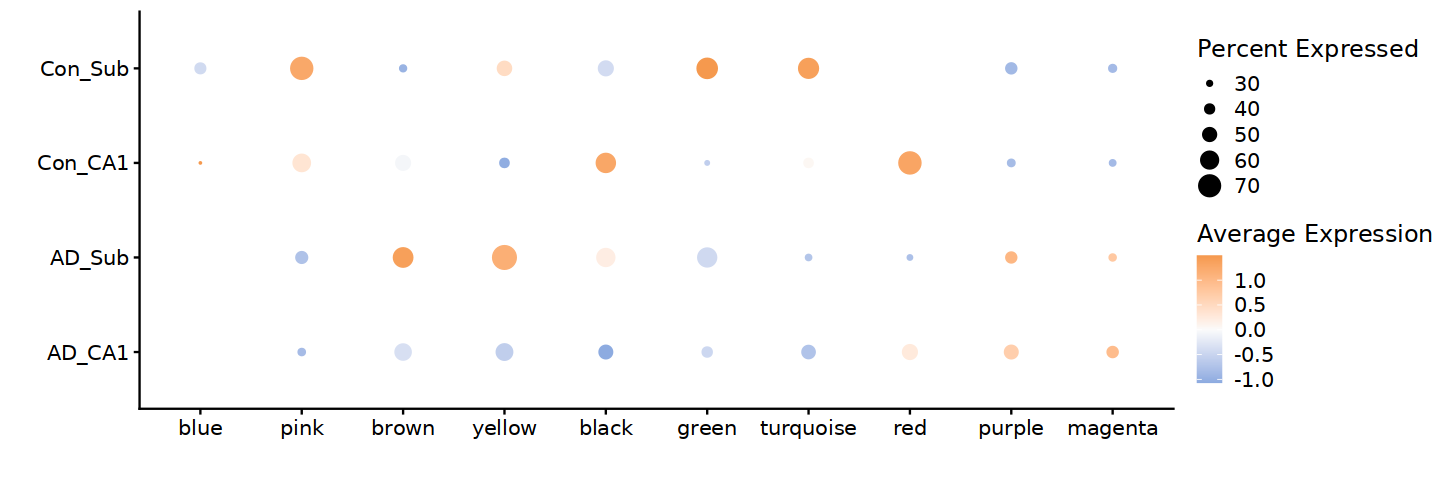

In [52]:
# plot with Seurat's DotPlot function
p <- DotPlot(seurat_obj, features=mods, group.by = 'group_area', dot.min=0.2)
p <- p +
  scale_color_gradient2(high='#f5994e', mid='#fbfbfb', low='#588dd5') +
  xlab('') + ylab('')
p
ggsave('/data/work/脑区划分/01_result/dotplot_module.pdf',height = 3.5,width = 7)

In [36]:
library(pheatmap)

# 准备注释数据
annotation_df <- data.frame(
  Module = gene_info[order(gene_info$module), "module"],
  row.names = gene_info[order(gene_info$module), "gene_name"]
)




# 计算模块分块间隔
gene_info_sorted <- gene_info[order(gene_info$module), ]
gene_order <- gene_info[order(gene_info$module), "gene_name"]
tom_matrix <- tom_matrix[gene_order, gene_order]

module_counts <- rle(gene_info_sorted$module)$lengths
gaps_positions <- cumsum(module_counts)[-length(module_counts)]


In [41]:
tom_matrix = readRDS('/data/work/脑区划分/00_data/CA1_Sub_tom.rds')
gene_info = read.csv('/data/work/脑区划分/01_result/Sub_CA1.Module.csv')
gene_info = gene_info[!gene_info$module=='grey',]

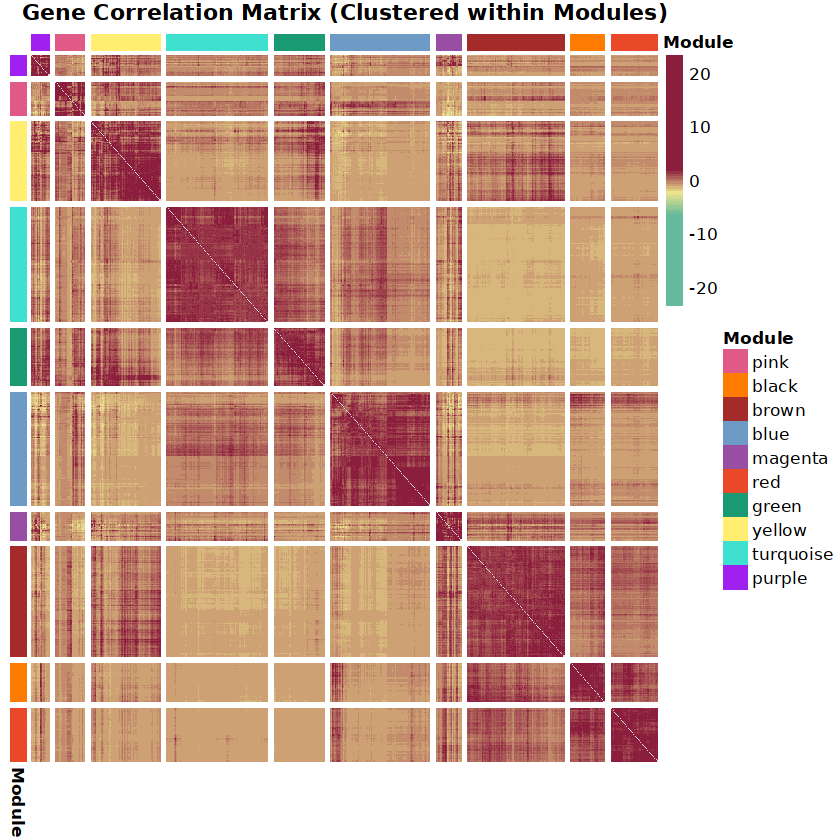

In [57]:
library(pheatmap)
gene_info$module = factor(gene_info$module,levels = c('purple','pink','yellow','turquoise','green','blue','magenta','brown','black','red'))
# 1. 准备数据和注释 (您提供的代码)
annotation_df <- data.frame(
  Module = gene_info[order(gene_info$module), "module"],
  row.names = gene_info[order(gene_info$module), "gene_name"]
)

module_colors <- list(
  Module = c(
     pink = "#e15987",
    black = "#fd7c01",
    brown = "brown",
    blue = "#6e9bc5",
    magenta = "#984EA3",
    red = "#e94829",
    green = "#199a73",
    yellow = "#ffee6f",
    turquoise = "turquoise",
     purple = 'purple'
  )
)
gene_info_sorted <- gene_info[order(gene_info$module), ]
gene_order <- gene_info[order(gene_info$module), "gene_name"]
tom_matrix <- tom_matrix[gene_order, gene_order]

# 2. 模块内聚类
clustered_gene_order <- c()  # 存储聚类后的基因顺序

for (module_name in unique(gene_info_sorted$module)) {
  # 提取当前模块的基因
  module_genes <- gene_info_sorted$gene_name[gene_info_sorted$module == module_name]
  module_matrix <- tom_matrix[module_genes, module_genes]

  # 清除对角线 (可选，根据您的需求)
  diag(module_matrix) <- NA

  # 聚类
  hc <- hclust(as.dist(1 - module_matrix), method = "ward.D2") # 使用 hclust 进行聚类

  # 获取聚类后的基因顺序
  module_clustered_genes <- module_genes[hc$order]
  clustered_gene_order <- c(clustered_gene_order, module_clustered_genes)
}

# 3. 重新排序矩阵和注释
tom_filtered <- tom_matrix[clustered_gene_order, clustered_gene_order]
diag(tom_filtered) <- NA # 再次清除对角线，确保在最终矩阵中没有自相关
tom_filtered = scale(tom_filtered, center = TRUE, scale = TRUE) # 标准化

annotation_df_reordered <- annotation_df[clustered_gene_order, , drop = FALSE] # 重新排序注释
# 重新计算 gaps_positions (因为基因顺序改变了)
annotation_df_reordered$Module = factor(annotation_df_reordered$Module ,levels = c('purple','pink','yellow','turquoise','green','blue','magenta','brown','black','red'))

module_reordered <- as.character(annotation_df_reordered$Module)  # 将因子转换为字符向量

module_counts_reordered <- rle(module_reordered)$lengths
gaps_positions_reordered <- cumsum(module_counts_reordered)[-length(module_counts_reordered)]


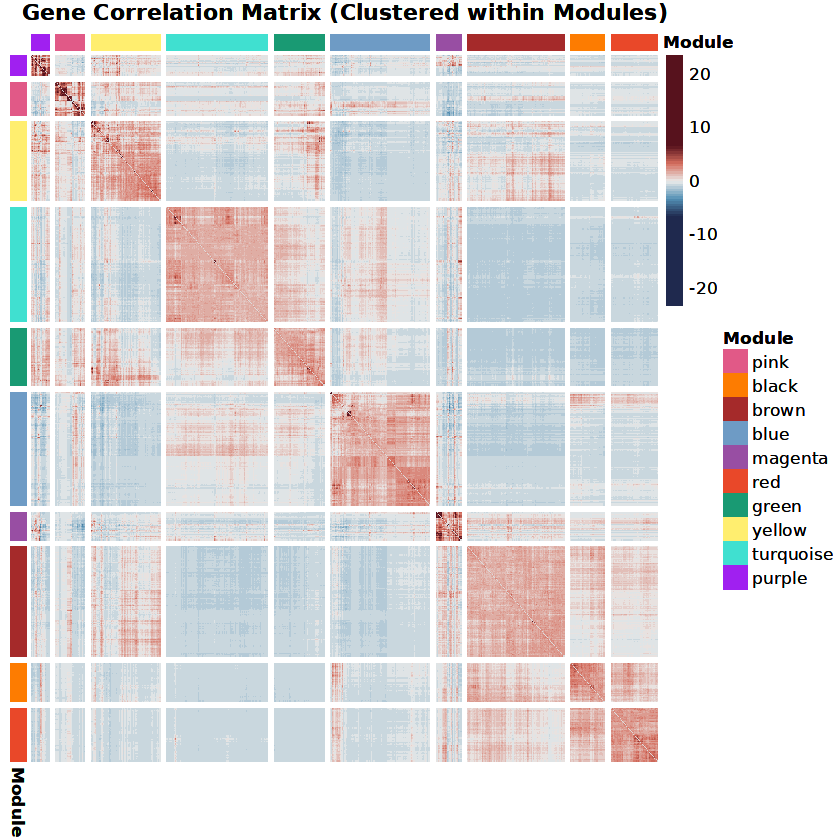

In [69]:
# Properly defined color palettes (only one should be active)
# mycolors <- c("#3b374c", "#44598e", "#64a0c0", "#7ec4b7", "#deebcd")  # 藏青-浅绿
# mycolors <- c("#073f82", "#1b71b4", "#58a4cf", "#a2cbe3", "#f2f9fe")  # 藏蓝-浅蓝
# mycolors <- c("#eeecdf", "#becdd2", "#6f9ad1", "#44679f", "#3f4f71")  # 藏蓝-水泥灰
# mycolors <- c("#492952", "#82677e", "white", "#59829e", "#1e4668")    # 脏紫-脏蓝
mycolors <- rev(c("#57121d", "#57121d","#57121d", "#57121d", "#57121d", "#57121d", "#d56e5e", "#eaebea", "#5390b5", "#1f294e", "#1f294e", "#1f294e", "#1f294e", "#1f294e", "#1f294e")) # 经典红-蓝

p <- pheatmap(
  tom_filtered,
  scale = 'row',
  cluster_rows = FALSE,
  cluster_cols = FALSE,
  annotation_row = annotation_df_reordered,
  annotation_col = annotation_df_reordered,
  annotation_colors = module_colors,
  show_rownames = FALSE,
  show_colnames = FALSE,
  gaps_row = gaps_positions_reordered,
  gaps_col = gaps_positions_reordered,
  color = colorRampPalette(mycolors)(100),
  main = "Gene Correlation Matrix (Clustered within Modules)",
  border_color = NA
)
p


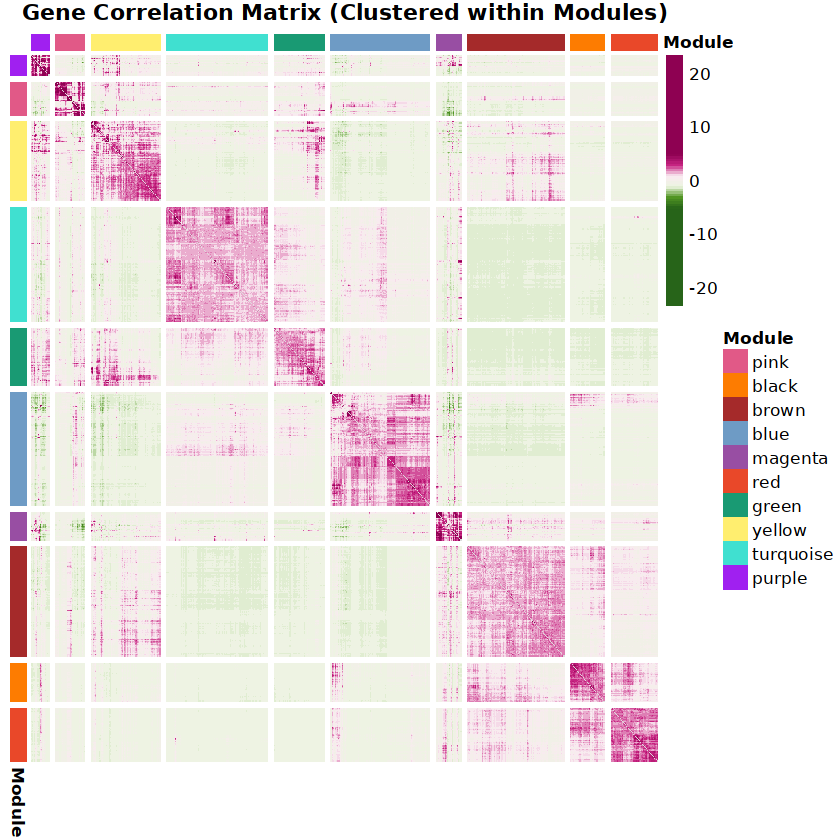

In [70]:
# 定义颜色序列，确保括号闭合
palette_colors <- rev(c(
  "#8E0152", "#8E0152", "#8E0152", "#8E0152", "#8E0152", "#8E0152", "#8E0152", "#8E0152", "#8E0152", "#8E0152",
  "#C72582",  "#FAEAF2",
   "#EDF5E1","#529624", 
  "#276419", "#276419", "#276419", "#276419", "#276419", "#276419", "#276419", "#276419", "#276419", "#276419"
))
library(pheatmap)
# 使用 colorRampPalette 创建调色板
color_palette <- colorRampPalette(palette_colors)(100)

# 生成 heatmap
p = pheatmap(
  tom_filtered,
  scale = 'row',
  cluster_rows = FALSE,
  cluster_cols = FALSE,
  annotation_row = annotation_df_reordered,
  annotation_col = annotation_df_reordered,
  annotation_colors = module_colors,
  show_rownames = FALSE,
  show_colnames = FALSE,
  gaps_row = gaps_positions_reordered,
  gaps_col = gaps_positions_reordered,
  # breaks = seq(0, quantile(tom_matrix, 0.1), length.out = 100),
  color = color_palette,
  main = "Gene Correlation Matrix (Clustered within Modules)",
  border_color = NA
)


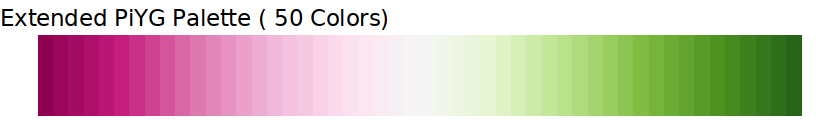

In [88]:
# 加载 RColorBrewer 包
library(RColorBrewer)

# 1. 展示默认的 11 色 PiYG 调色板
# display.brewer.pal(11, "PiYG")  # 原始 11 色

# 2. 生成扩展的 21 色 PiYG 渐变
n_colors <- 50  # 自定义颜色数量
piyg_colors <- colorRampPalette(brewer.pal(11, "PiYG"))(n_colors)  # 通过插值生成更多颜色

options(repr.plot.height = 1)

# 方法二：使用 ggplot2
library(ggplot2)
ggplot(data.frame(x = 1:n_colors, y = 1, color = factor(1:n_colors))) +
  geom_tile(aes(x = x, y = y, fill = color), show.legend = FALSE) +
  scale_fill_manual(values = piyg_colors) +
  theme_void() +
  labs(title = paste("Extended PiYG Palette (", n_colors, "Colors)"))


In [89]:
save_pheatmap_pdf <- function(x, filename, width=8, height=7) {
   stopifnot(!missing(x))
   stopifnot(!missing(filename))
   pdf(filename, width=width, height=height)
   grid::grid.newpage()
   grid::grid.draw(x$gtable)
   dev.off()
}

save_pheatmap_pdf(p,'/data/work/脑区划分/01_result/module.png',height = 7,width = 8)


png 
  2

In [63]:
#######brown 富集分析
terms = c('oxidative phosphorylation', 'cellular respiration','ATP synthesis coupled electron transport',
          'mitochondrial ATP synthesis coupled electron transport','energy derivation by oxidation of organic compounds',
          'electron transport chain')
GO.combined.filter = read.table("/data/users/liuyuyang/online/08.脑区划分/02.result/01.bin100/05.AD/04.wgcna/03.hdWGCNA.module_GO.filter.txt",sep="\t",check.names=F,header=T,stringsAsFactors = FALSE,quote = "")
GO.combined.filter = GO.combined.filter[GO.combined.filter$cluster=='brown',]
GO.combined.filter = GO.combined.filter[GO.combined.filter$Description%in%terms,]

In [91]:
GO.combined.filter = read.table("/data/users/liuyuyang/online/08.脑区划分/02.result/01.bin100/05.AD/04.wgcna/03.hdWGCNA.module_GO.filter.txt",sep="\t",check.names=F,header=T,stringsAsFactors = FALSE,quote = "")
table(GO.combined.filter$cluster)


    black      blue     brown     green   magenta      pink    purple       red 
      129       150       209        58        51       293       295       475 
turquoise    yellow 
       53       100 

In [67]:
head(GO.combined.filter)

,ONTOLOGY,ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count,cluster
,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<chr>
444,BP,GO:0006119,oxidative phosphorylation,47/121,147/18903,1.269394e-69,1.656560e-66,1.459135e-66,NDUFA4/COX6C/COX8A/COX7C/NDUFB1/ATP5F1E/NDUFS5/COX5B/NDUFB4/ATP5MF/COX4I1/NDUFA1/NDUFB3/ISCU/NDUFB11/COX6B1/COX7A2/ATP5PD/COX7B/NDUFA13/COX6A1/ATP5PF/PARK7/UQCRB/UQCRQ/UQCR11/UQCRH/NDUFB7/ATP5ME/NDUFC1/UQCR10/NDUFB2/ATP5F1D/NDUFA8/NDUFB6/ATP5MG/ATP5PO/COA6/NDUFA12/NDUFB10/CYCS/CYC1/NDUFA2/COX5A/NDUFS6/NDUFAB1/NDUFB8,47,brown
446,BP,GO:0045333,cellular respiration,48/121,240/18903,4.541223e-60,1.975432e-57,1.740005e-57,NDUFA4/COX6C/COX8A/COX7C/NDUFB1/ATP5F1E/NDUFS5/COX5B/NDUFB4/ATP5MF/COX4I1/NDUFA1/NDUFB3/ISCU/NDUFB11/COX6B1/COX7A2/ATP5PD/COX7B/NDUFA13/COX6A1/ATP5PF/PARK7/UQCRB/UQCRQ/UQCR11/UQCRH/NDUFB7/ATP5ME/NDUFC1/UQCR10/NDUFB2/ATP5F1D/NDUFA8/NDUFB6/ATP5MG/ATP5PO/COA6/NDUFA12/MTLN/NDUFB10/CYCS/CYC1/NDUFA2/COX5A/NDUFS6/NDUFAB1/NDUFB8,48,brown
447,BP,GO:0042773,ATP synthesis coupled electron transport,37/121,101/18903,6.063094e-57,1.582467e-54,1.393873e-54,NDUFA4/COX6C/COX8A/COX7C/NDUFB1/NDUFS5/COX5B/NDUFB4/COX4I1/NDUFA1/NDUFB3/ISCU/COX6B1/COX7A2/COX7B/COX6A1/PARK7/UQCRB/UQCRQ/UQCR11/UQCRH/NDUFB7/NDUFC1/UQCR10/NDUFB2/NDUFA8/NDUFB6/COA6/NDUFA12/NDUFB10/CYCS/CYC1/NDUFA2/COX5A/NDUFS6/NDUFAB1/NDUFB8,37,brown
448,BP,GO:0042775,mitochondrial ATP synthesis coupled electron transport,37/121,101/18903,6.063094e-57,1.582467e-54,1.393873e-54,NDUFA4/COX6C/COX8A/COX7C/NDUFB1/NDUFS5/COX5B/NDUFB4/COX4I1/NDUFA1/NDUFB3/ISCU/COX6B1/COX7A2/COX7B/COX6A1/PARK7/UQCRB/UQCRQ/UQCR11/UQCRH/NDUFB7/NDUFC1/UQCR10/NDUFB2/NDUFA8/NDUFB6/COA6/NDUFA12/NDUFB10/CYCS/CYC1/NDUFA2/COX5A/NDUFS6/NDUFAB1/NDUFB8,37,brown
451,BP,GO:0015980,energy derivation by oxidation of organic compounds,48/121,333/18903,9.407648e-53,1.534623e-50,1.351730e-50,NDUFA4/COX6C/COX8A/COX7C/NDUFB1/ATP5F1E/NDUFS5/COX5B/NDUFB4/ATP5MF/COX4I1/NDUFA1/NDUFB3/ISCU/NDUFB11/COX6B1/COX7A2/ATP5PD/COX7B/NDUFA13/COX6A1/ATP5PF/PARK7/UQCRB/UQCRQ/UQCR11/UQCRH/NDUFB7/ATP5ME/NDUFC1/UQCR10/NDUFB2/ATP5F1D/NDUFA8/NDUFB6/ATP5MG/ATP5PO/COA6/NDUFA12/MTLN/NDUFB10/CYCS/CYC1/NDUFA2/COX5A/NDUFS6/NDUFAB1/NDUFB8,48,brown
452,BP,GO:0022900,electron transport chain,37/121,176/18903,1.210713e-46,1.755534e-44,1.546314e-44,NDUFA4/COX6C/COX8A/COX7C/NDUFB1/NDUFS5/COX5B/NDUFB4/COX4I1/NDUFA1/NDUFB3/ISCU/COX6B1/COX7A2/COX7B/COX6A1/PARK7/UQCRB/UQCRQ/UQCR11/UQCRH/NDUFB7/NDUFC1/UQCR10/NDUFB2/NDUFA8/NDUFB6/COA6/NDUFA12/NDUFB10/CYCS/CYC1/NDUFA2/COX5A/NDUFS6/NDUFAB1/NDUFB8,37,brown


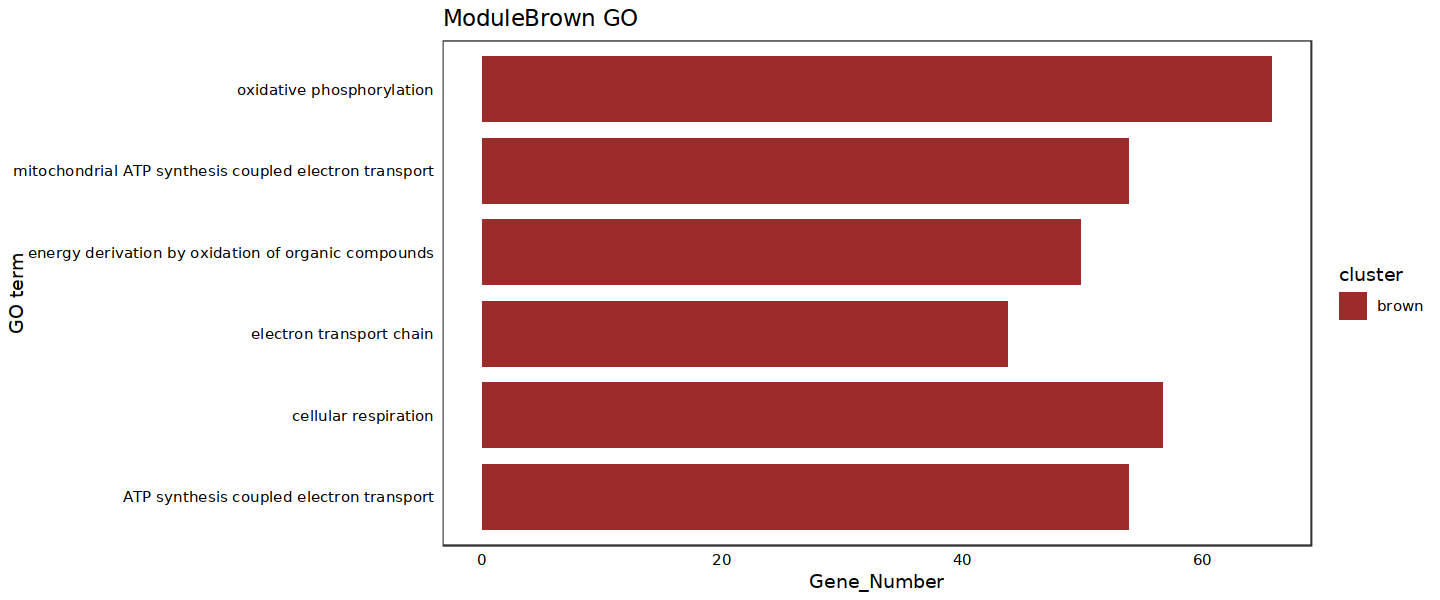

In [70]:

#############################barplot
p1 = ggplot(GO.combined.filter,
       aes(x=Description,y=-log10(p.adjust), fill=cluster)) + #x、y轴定义；根据type填充颜色
       geom_bar(stat="identity", width=0.8) +  #柱状图宽度
       # scale_fill_manual(values = cols ) +  #柱状图填充颜色
       scale_fill_manual(values = '#9D2B29')+#(low = "lightred", high = "darkred") + #连续型
       # scale_y_continuous(limits = c(0,25))+
       coord_flip() +  #让柱状图变为纵向
       xlab("GO term") +  #x轴标签
       ylab("Gene_Number") +  #y轴标签
       labs(title = 'ModuleBrown GO')+  #设置标题
       theme_bw()+
       theme(panel.grid=element_blank(),
             axis.text.x = element_text(colour = "black"),
             axis.text.y = element_text(colour = "black"),
             # axis.text.y = element_blank(),
             axis.ticks.y = element_blank(),
             # axis.text.x = element_blank(),
             axis.ticks.x = element_blank())
options(repr.plot.height = 5)
p1

ggsave('03.ModuleBrown.GOBP.bar.pdf',p1,width = 7,height = 3)

In [27]:
library(Seurat)
library(ggplot2)

In [28]:
####brown addmodule score

seurat_obj = readRDS('/data/users/liuyuyang/online/08.脑区划分/02.result/01.bin100/05.AD/04.wgcna/pca.bin_Sub_CA1.hdWGCNA_object_total.rds')

In [29]:
genelist = read.csv('/data/work/Region-division/01_result/Sub_CA1.Module.csv')
table(genelist$module)
genelist = list(genelist[genelist$module=='brown',]$gene)


    black      blue     brown     green      grey   magenta      pink    purple 
       48       141       137        71       611        35        41        25 
      red turquoise    yellow 
       66       143        98 

In [30]:
alldata <- AddModuleScore( object = seurat_obj, 
                             features = genelist, ctrl = 100, 
                              name = 'brown' 
                            )

In [31]:
head(alldata)

,orig.ident,nCount_RNA,nFeature_RNA,chip,nFeature_Spatial,nCount_Spatial,rx,ry,rx.m,ry.m,⋯,coor_y,coor_x,row,col,cell,label,group,person,metacell_grouping,brown1
,<chr>,<dbl>,<int>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>
Con1.1_Con1.1_BIN100_491,Con1.1,3422,951,Con1.1,951,3422,0,0,0,477,⋯,477,0,NA,NA,NA,Con1.1_NA_NA,Con,Con1,Sub#Con,0.5219798
Con1.1_Con1.1_BIN100_518,Con1.1,2166,865,Con1.1,865,2166,0,0,0,450,⋯,450,0,NA,NA,NA,Con1.1_NA_NA,Con,Con1,Sub#Con,1.0225311
Con1.1_Con1.1_BIN100_520,Con1.1,2148,871,Con1.1,871,2148,0,0,0,448,⋯,448,0,NA,NA,NA,Con1.1_NA_NA,Con,Con1,Sub#Con,0.9880164
Con1.1_Con1.1_BIN100_522,Con1.1,2815,698,Con1.1,698,2815,0,0,0,446,⋯,446,0,NA,NA,NA,Con1.1_NA_NA,Con,Con1,Sub#Con,0.6602577
Con1.1_Con1.1_BIN100_530,Con1.1,2816,674,Con1.1,674,2816,0,0,0,438,⋯,438,0,NA,NA,NA,Con1.1_NA_NA,Con,Con1,Sub#Con,0.5404399
Con1.1_Con1.1_BIN100_535,Con1.1,2635,656,Con1.1,656,2635,0,0,0,433,⋯,433,0,NA,NA,NA,Con1.1_NA_NA,Con,Con1,Sub#Con,0.5708265
Con1.1_Con1.1_BIN100_542,Con1.1,2851,701,Con1.1,701,2851,0,0,0,426,⋯,426,0,NA,NA,NA,Con1.1_NA_NA,Con,Con1,Sub#Con,0.3401097
Con1.1_Con1.1_BIN100_551,Con1.1,3265,927,Con1.1,927,3265,0,0,0,417,⋯,417,0,NA,NA,NA,Con1.1_NA_NA,Con,Con1,Sub#Con,0.5204543
Con1.1_Con1.1_BIN100_555,Con1.1,3225,874,Con1.1,874,3225,0,0,0,413,⋯,413,0,NA,NA,NA,Con1.1_NA_NA,Con,Con1,Sub#Con,0.5291264


In [33]:
alldata@meta.data[alldata@meta.data$sample%in%c('Con5.1','Con5.2','Con6.1','Con6.2'),]$coor_x = alldata@meta.data[alldata@meta.data$sample%in%c('Con5.1','Con5.2','Con6.1','Con6.2'),]$coor_x-500
alldata@meta.data[alldata@meta.data$sample%in%c('Con8.1','Con8.2'),]$coor_x = alldata@meta.data[alldata@meta.data$sample%in%c('Con8.1','Con8.2'),]$coor_x-1100
alldata@meta.data[alldata@meta.data$sample%in%c('AD4.1','AD4.2','AD5.1','AD5.2','AD6.1','AD6.2','AD8.1','AD8.2'),]$coor_x = alldata@meta.data[alldata@meta.data$sample%in%c('AD4.1','AD4.2','AD5.1','AD5.2','AD6.1','AD6.2','AD8.1','AD8.2'),]$coor_x-1100
alldata@meta.data[alldata@meta.data$sample%in%c('AD7.1','AD7.2'),]$coor_x = alldata@meta.data[alldata@meta.data$sample%in%c('AD7.1','AD7.2'),]$coor_x-1000
alldata@meta.data[alldata@meta.data$sample%in%c('AD2.1','AD2.2'),]$coor_x = alldata@meta.data[alldata@meta.data$sample%in%c('AD2.1','AD2.2'),]$coor_x-500

In [34]:
options(repr.plot.width = 30, repr.plot.height = 10)
line = readRDS('/data/users/liuyuyang/online/08.脑区划分/02.result/01.bin100/05.AD/01.lines/02.bin.AD_Con.CA1_Sub_split.line.rds')
# 若需要强调高表达区域，可调整颜色权重
cols = colorRampPalette(c("white","white", "#FFC078",  "brown","brown"))(100)

# Subset the data for Con3.1 and line data for Con3_1
Con = alldata@meta.data


p1 <- ggplot(Con, aes(x = coor_x, y = coor_y, color = brown1)) +
  geom_point(size = 0.001) +
  scale_color_gradientn(colors = cols) +  # , limits = c(-2, 2) Set color scale limits to 0-0.5
  theme_classic() + 
  coord_fixed() #+ 
  # geom_point(data = line, aes(x = coor_x, y = coor_y), size = 0.000001, color = "black")

# Display the plot
# p1

# Save the plot if needed
ggsave('24chips_CA1-Sub-brown-bin.pdf', width = 50, height = 8,limitsize = FALSE)


Warning message in (function (mapping = NULL, data = NULL, stat = "ydensity", position = "dodge", :
“Ignoring unknown aesthetics: scale”


ERROR: [1m[33mError[39m in `ggsave()`:[22m
[1m[22m[33m![39m Cannot find directory [34m/data/work/09_FigureV3/Figure_neuron[39m.
[36mℹ[39m Please supply an existing directory or use `create.dir = TRUE`.


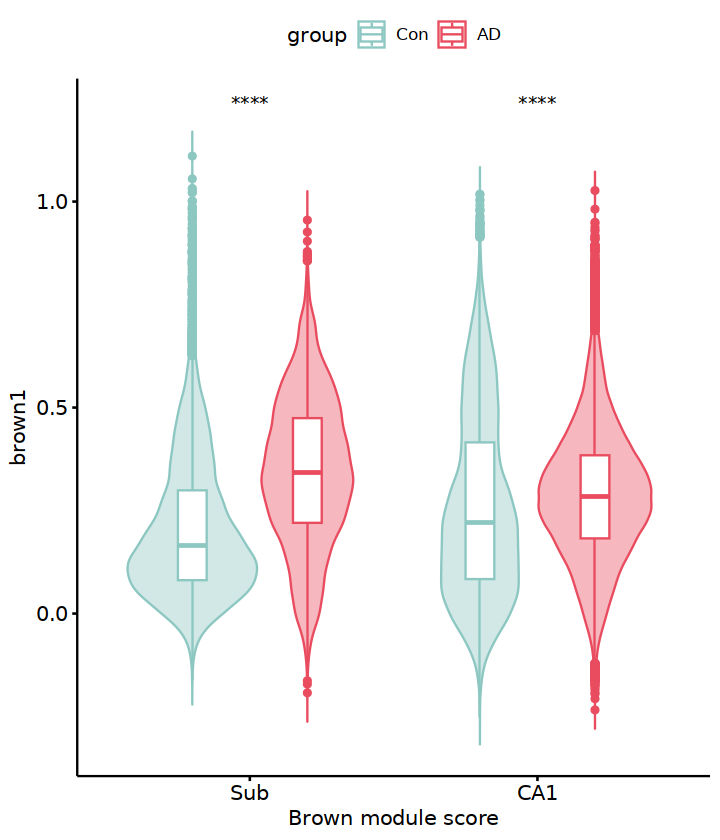

In [83]:

result = seurat_obj@meta.data
options(repr.plot.width = 6, repr.plot.height = 7)   ## 图像界面宽度显示设置
cols = c("#8dc7c2", "#e94c5f")
library(ggplot2)
library(reshape2)
library(ggpubr)
library(ggsignif)  #添加显著性标记
# 将 sample 转换为因子，并指定顺序
result$group = factor(result$group, levels = c('Con', 'AD'))

mycolor = c("#8dc7c2", "#e94c5f")
p1 <- ggviolin(result, x = "area",
y = "brown1",
color = "group",
fill = "group",
alpha =0.4,
width=0.9,
add = "boxplot",add.params = list(fill = "white"))+
guides(fill = "none")+
xlab('Brown module score')+
scale_colour_manual(values=alpha(mycolor,1))+
scale_fill_manual(values=alpha(mycolor,0.5))+ 
stat_compare_means(aes(x = area, y = brown1, group = group), 
                       data = result, method = "t.test", 
                       label = "p.signif", 
                       label.y = max(result$brown1) * 1.1)

p1

# 如果需要保存图形，可以使用 ggsave
ggsave("/data/work/脑区划分/01_result/brown1.pdf", height = 5, width = 7)


In [84]:
ggsave("/data/work/脑区划分/01_result/brown1.pdf", height = 5, width = 7)



    black      blue     brown     green      grey   magenta      pink    purple 
       48       141       137        71       611        35        41        25 
      red turquoise    yellow 
       66       143        98 

Warning message in (function (mapping = NULL, data = NULL, stat = "ydensity", position = "dodge", :
“Ignoring unknown aesthetics: scale”


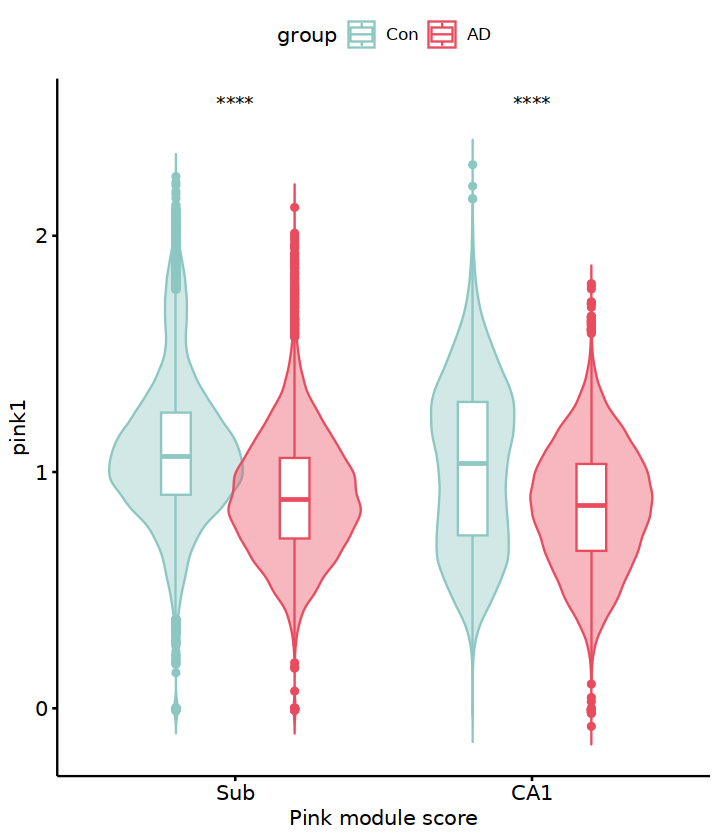

In [16]:
genelist = read.csv('/data/work/脑区划分/01_result/Sub_CA1.Module.csv')
table(genelist$module)
genelist = list(genelist[genelist$module=='pink',]$gene)
seurat_obj <- AddModuleScore( object = seurat_obj, 
                             features = genelist, ctrl = 100, 
                              name = 'pink' 
                            )

result = seurat_obj@meta.data
options(repr.plot.width = 6, repr.plot.height = 7)   ## 图像界面宽度显示设置
cols = c("#8dc7c2", "#e94c5f")
library(ggplot2)
library(reshape2)
library(ggpubr)
library(ggsignif)  #添加显著性标记
# 将 sample 转换为因子，并指定顺序
result$group = factor(result$group, levels = c('Con', 'AD'))

mycolor = c("#8dc7c2", "#e94c5f")
p1 <- ggviolin(result, x = "area",
y = "pink1",
color = "group",
fill = "group",
alpha =0.4,
width=0.9,
add = "boxplot",add.params = list(fill = "white"))+
guides(fill = "none")+
xlab('Pink module score')+
scale_colour_manual(values=alpha(mycolor,1))+
scale_fill_manual(values=alpha(mycolor,0.5))+ 
stat_compare_means(aes(x = area, y = pink1, group = group), 
                       data = result, method = "t.test", 
                       label = "p.signif", 
                       label.y = max(result$pink1) * 1.1)

p1

# 如果需要保存图形，可以使用 ggsave
ggsave("/data/work/脑区划分/01_result/pink1.pdf", height = 5, width = 7)



    black      blue     brown     green      grey   magenta      pink    purple 
       48       141       137        71       611        35        41        25 
      red turquoise    yellow 
       66       143        98 

Warning message in (function (mapping = NULL, data = NULL, stat = "ydensity", position = "dodge", :
“Ignoring unknown aesthetics: scale”


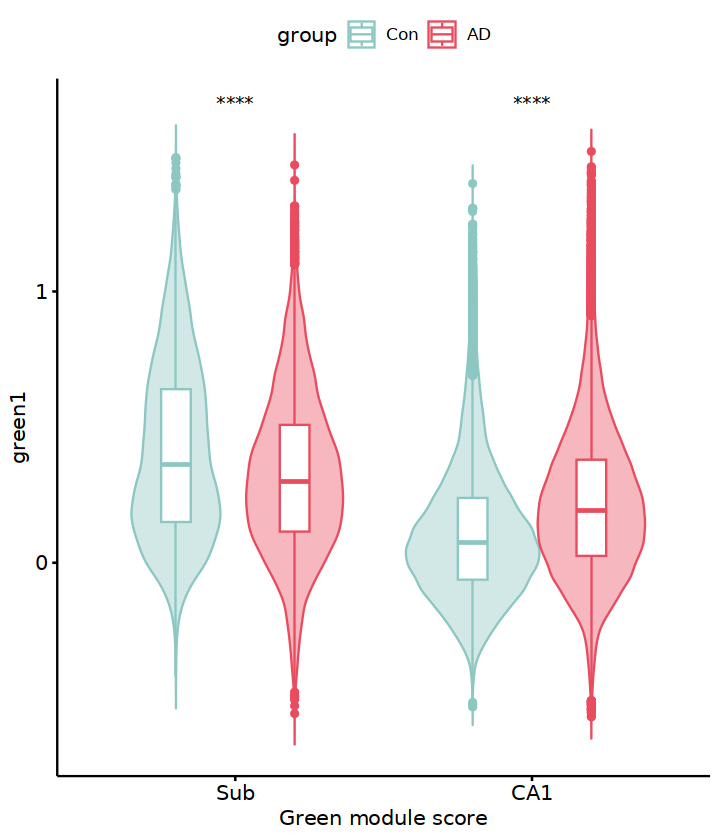

In [17]:
genelist = read.csv('/data/work/脑区划分/01_result/Sub_CA1.Module.csv')
table(genelist$module)
genelist = list(genelist[genelist$module=='green',]$gene)
seurat_obj <- AddModuleScore( object = seurat_obj, 
                             features = genelist, ctrl = 100, 
                              name = 'green' 
                            )

result = seurat_obj@meta.data
options(repr.plot.width = 6, repr.plot.height = 7)   ## 图像界面宽度显示设置
cols = c("#8dc7c2", "#e94c5f")
library(ggplot2)
library(reshape2)
library(ggpubr)
library(ggsignif)  #添加显著性标记
# 将 sample 转换为因子，并指定顺序
result$group = factor(result$group, levels = c('Con', 'AD'))

mycolor = c("#8dc7c2", "#e94c5f")
p1 <- ggviolin(result, x = "area",
y = "green1",
color = "group",
fill = "group",
alpha =0.4,
width=0.9,
add = "boxplot",add.params = list(fill = "white"))+
guides(fill = "none")+
xlab('Green module score')+
scale_colour_manual(values=alpha(mycolor,1))+
scale_fill_manual(values=alpha(mycolor,0.5))+ 
stat_compare_means(aes(x = area, y = green1, group = group), 
                       data = result, method = "t.test", 
                       label = "p.signif", 
                       label.y = max(result$green1) * 1.1)

p1

# 如果需要保存图形，可以使用 ggsave
ggsave("/data/work/脑区划分/01_result/green1.pdf", height = 5, width = 7)



    black      blue     brown     green      grey   magenta      pink    purple 
       48       141       137        71       611        35        41        25 
      red turquoise    yellow 
       66       143        98 

Warning message in (function (mapping = NULL, data = NULL, stat = "ydensity", position = "dodge", :
“Ignoring unknown aesthetics: scale”


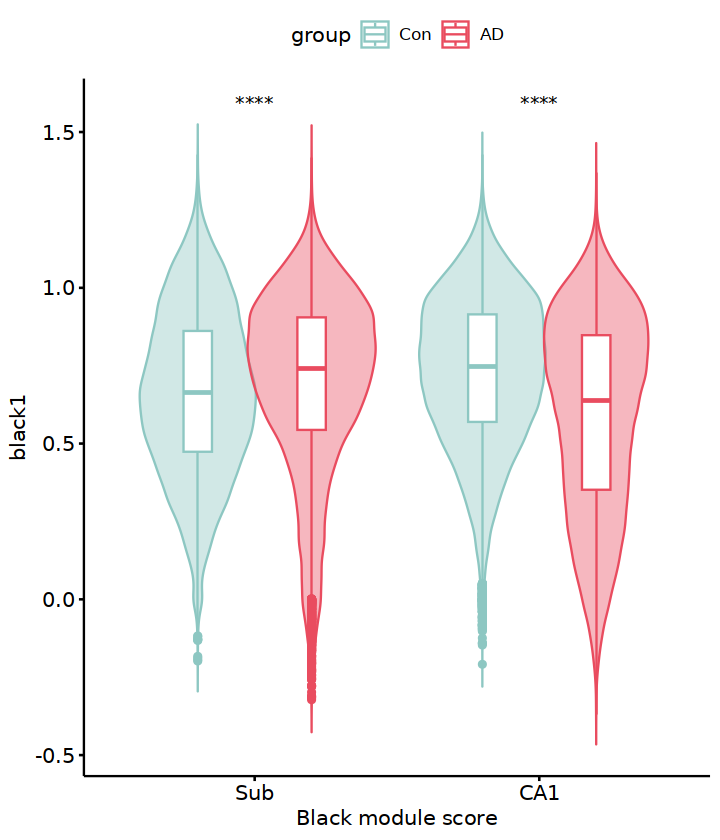

In [18]:
genelist = read.csv('/data/work/脑区划分/01_result/Sub_CA1.Module.csv')
table(genelist$module)
genelist = list(genelist[genelist$module=='black',]$gene)
seurat_obj <- AddModuleScore( object = seurat_obj, 
                             features = genelist, ctrl = 100, 
                              name = 'black' 
                            )

result = seurat_obj@meta.data
options(repr.plot.width = 6, repr.plot.height = 7)   ## 图像界面宽度显示设置
cols = c("#8dc7c2", "#e94c5f")
library(ggplot2)
library(reshape2)
library(ggpubr)
library(ggsignif)  #添加显著性标记
# 将 sample 转换为因子，并指定顺序
result$group = factor(result$group, levels = c('Con', 'AD'))

mycolor = c("#8dc7c2", "#e94c5f")
p1 <- ggviolin(result, x = "area",
y = "black1",
color = "group",
fill = "group",
alpha =0.4,
width=0.9,
add = "boxplot",add.params = list(fill = "white"))+
guides(fill = "none")+
xlab('Black module score')+
scale_colour_manual(values=alpha(mycolor,1))+
scale_fill_manual(values=alpha(mycolor,0.5))+ 
stat_compare_means(aes(x = area, y = black1, group = group), 
                       data = result, method = "t.test", 
                       label = "p.signif", 
                       label.y = max(result$black1) * 1.1)

p1

# 如果需要保存图形，可以使用 ggsave
ggsave("/data/work/脑区划分/01_result/black1.pdf", height = 5, width = 7)



    black      blue     brown     green      grey   magenta      pink    purple 
       48       141       137        71       611        35        41        25 
      red turquoise    yellow 
       66       143        98 

Warning message in (function (mapping = NULL, data = NULL, stat = "ydensity", position = "dodge", :
“Ignoring unknown aesthetics: scale”


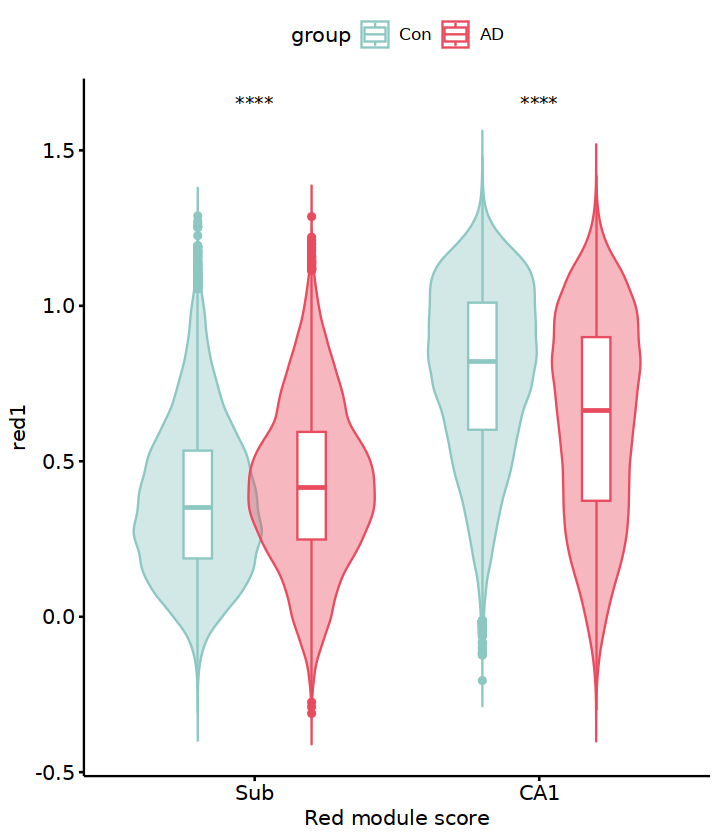

In [19]:
genelist = read.csv('/data/work/脑区划分/01_result/Sub_CA1.Module.csv')
table(genelist$module)
genelist = list(genelist[genelist$module=='red',]$gene)
seurat_obj <- AddModuleScore( object = seurat_obj, 
                             features = genelist, ctrl = 100, 
                              name = 'red' 
                            )

result = seurat_obj@meta.data
options(repr.plot.width = 6, repr.plot.height = 7)   ## 图像界面宽度显示设置
cols = c("#8dc7c2", "#e94c5f")
library(ggplot2)
library(reshape2)
library(ggpubr)
library(ggsignif)  #添加显著性标记
# 将 sample 转换为因子，并指定顺序
result$group = factor(result$group, levels = c('Con', 'AD'))

mycolor = c("#8dc7c2", "#e94c5f")
p1 <- ggviolin(result, x = "area",
y = "red1",
color = "group",
fill = "group",
alpha =0.4,
width=0.9,
add = "boxplot",add.params = list(fill = "white"))+
guides(fill = "none")+
xlab('Red module score')+
scale_colour_manual(values=alpha(mycolor,1))+
scale_fill_manual(values=alpha(mycolor,0.5))+ 
stat_compare_means(aes(x = area, y =red1, group = group), 
                       data = result, method = "t.test", 
                       label = "p.signif", 
                       label.y = max(result$red1) * 1.1)

p1

# 如果需要保存图形，可以使用 ggsave
ggsave("/data/work/脑区划分/01_result/red1.pdf", height = 5, width = 7)



    black      blue     brown     green      grey   magenta      pink    purple 
       48       141       137        71       611        35        41        25 
      red turquoise    yellow 
       66       143        98 

Warning message in (function (mapping = NULL, data = NULL, stat = "ydensity", position = "dodge", :
“Ignoring unknown aesthetics: scale”


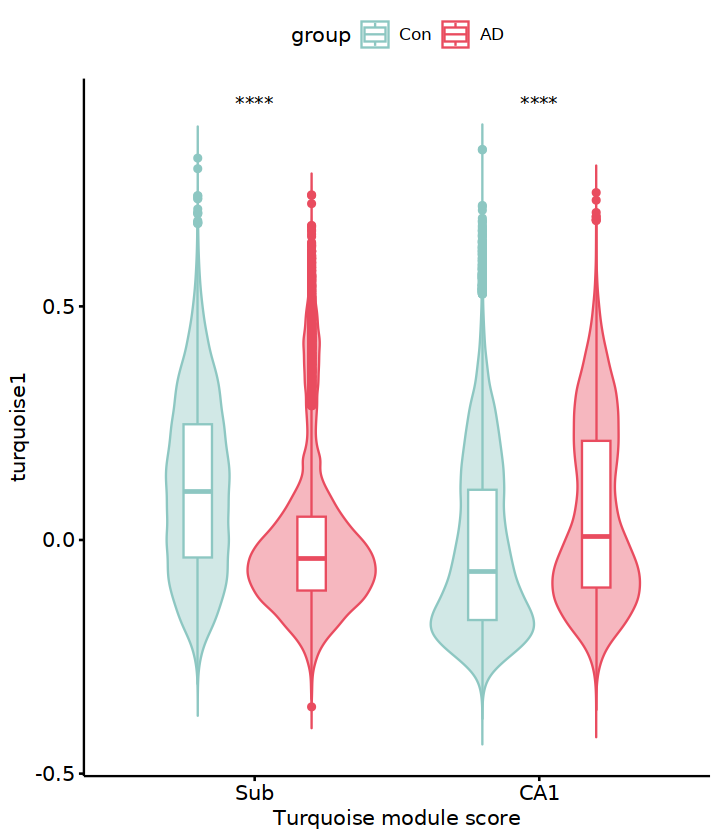

In [20]:
genelist = read.csv('/data/work/脑区划分/01_result/Sub_CA1.Module.csv')
table(genelist$module)
genelist = list(genelist[genelist$module=='turquoise',]$gene)
seurat_obj <- AddModuleScore( object = seurat_obj, 
                             features = genelist, ctrl = 100, 
                              name = 'turquoise' 
                            )

result = seurat_obj@meta.data
options(repr.plot.width = 6, repr.plot.height = 7)   ## 图像界面宽度显示设置
cols = c("#8dc7c2", "#e94c5f")
library(ggplot2)
library(reshape2)
library(ggpubr)
library(ggsignif)  #添加显著性标记
# 将 sample 转换为因子，并指定顺序
result$group = factor(result$group, levels = c('Con', 'AD'))

mycolor = c("#8dc7c2", "#e94c5f")
p1 <- ggviolin(result, x = "area",
y = "turquoise1",
color = "group",
fill = "group",
alpha =0.4,
width=0.9,
add = "boxplot",add.params = list(fill = "white"))+
guides(fill = "none")+
xlab('Turquoise module score')+
scale_colour_manual(values=alpha(mycolor,1))+
scale_fill_manual(values=alpha(mycolor,0.5))+ 
stat_compare_means(aes(x = area, y =turquoise1, group = group), 
                       data = result, method = "t.test", 
                       label = "p.signif", 
                       label.y = max(result$turquoise1) * 1.1)

p1

# 如果需要保存图形，可以使用 ggsave
ggsave("/data/work/脑区划分/01_result/turquoise1.pdf", height = 5, width = 7)



    black      blue     brown     green      grey   magenta      pink    purple 
       48       141       137        71       611        35        41        25 
      red turquoise    yellow 
       66       143        98 

Warning message in (function (mapping = NULL, data = NULL, stat = "ydensity", position = "dodge", :
“Ignoring unknown aesthetics: scale”


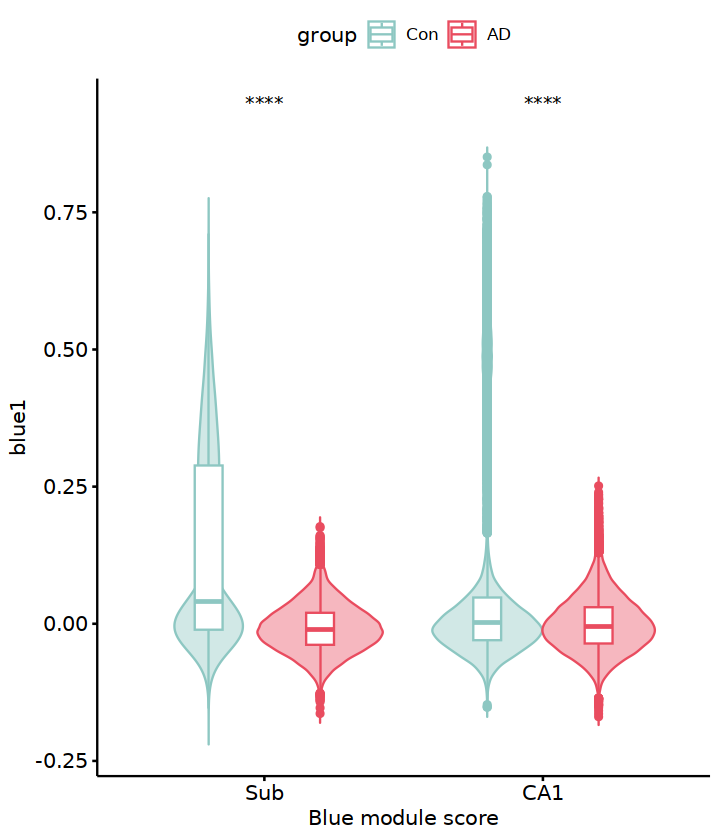

In [21]:
genelist = read.csv('/data/work/脑区划分/01_result/Sub_CA1.Module.csv')
table(genelist$module)
genelist = list(genelist[genelist$module=='blue',]$gene)
seurat_obj <- AddModuleScore( object = seurat_obj, 
                             features = genelist, ctrl = 100, 
                              name = 'blue' 
                            )

result = seurat_obj@meta.data
options(repr.plot.width = 6, repr.plot.height = 7)   ## 图像界面宽度显示设置
cols = c("#8dc7c2", "#e94c5f")
library(ggplot2)
library(reshape2)
library(ggpubr)
library(ggsignif)  #添加显著性标记
# 将 sample 转换为因子，并指定顺序
result$group = factor(result$group, levels = c('Con', 'AD'))

mycolor = c("#8dc7c2", "#e94c5f")
p1 <- ggviolin(result, x = "area",
y = "blue1",
color = "group",
fill = "group",
alpha =0.4,
width=0.9,
add = "boxplot",add.params = list(fill = "white"))+
guides(fill = "none")+
xlab('Blue module score')+
scale_colour_manual(values=alpha(mycolor,1))+
scale_fill_manual(values=alpha(mycolor,0.5))+ 
stat_compare_means(aes(x = area, y =blue1, group = group), 
                       data = result, method = "t.test", 
                       label = "p.signif", 
                       label.y = max(result$blue1) * 1.1)

p1

# 如果需要保存图形，可以使用 ggsave
ggsave("/data/work/脑区划分/01_result/blue1.pdf", height = 5, width = 7)



    black      blue     brown     green      grey   magenta      pink    purple 
       48       141       137        71       611        35        41        25 
      red turquoise    yellow 
       66       143        98 

Warning message in (function (mapping = NULL, data = NULL, stat = "ydensity", position = "dodge", :
“Ignoring unknown aesthetics: scale”


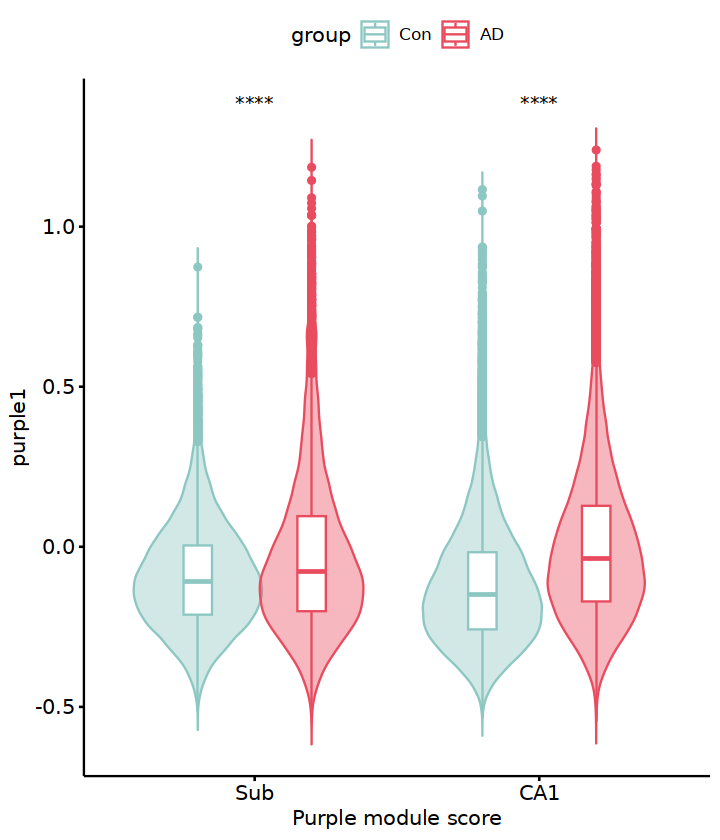

In [22]:
genelist = read.csv('/data/work/脑区划分/01_result/Sub_CA1.Module.csv')
table(genelist$module)
genelist = list(genelist[genelist$module=='purple',]$gene)
seurat_obj <- AddModuleScore( object = seurat_obj, 
                             features = genelist, ctrl = 100, 
                              name = 'purple' 
                            )

result = seurat_obj@meta.data
options(repr.plot.width = 6, repr.plot.height = 7)   ## 图像界面宽度显示设置
cols = c("#8dc7c2", "#e94c5f")
library(ggplot2)
library(reshape2)
library(ggpubr)
library(ggsignif)  #添加显著性标记
# 将 sample 转换为因子，并指定顺序
result$group = factor(result$group, levels = c('Con', 'AD'))

mycolor = c("#8dc7c2", "#e94c5f")
p1 <- ggviolin(result, x = "area",
y = "purple1",
color = "group",
fill = "group",
alpha =0.4,
width=0.9,
add = "boxplot",add.params = list(fill = "white"))+
guides(fill = "none")+
xlab('Purple module score')+
scale_colour_manual(values=alpha(mycolor,1))+
scale_fill_manual(values=alpha(mycolor,0.5))+ 
stat_compare_means(aes(x = area, y =purple1, group = group), 
                       data = result, method = "t.test", 
                       label = "p.signif", 
                       label.y = max(result$purple1) * 1.1)

p1

# 如果需要保存图形，可以使用 ggsave
ggsave("/data/work/脑区划分/01_result/purple1.pdf", height = 5, width = 7)


In [ ]:
####spatial plot